# DCQHGT Topology Cold-OD v2

This notebook trains and evaluates the **topology-aware D-CQHGT v2** model on the FREIGHT-MNet Cold-OD split.

The v2 changes are intentionally focused and conservative:

1. **PyG kernel preflight.** The notebook stops before importing pandas / PyG if it is accidentally launched in the Anaconda base kernel that caused the NumPy ABI and `torch_geometric` errors.
2. **Truck and rail topology directionality QA.** The notebook checks whether `truck_adj` and `rail_adj` are bidirectional.
3. **Automatic bidirectional repair.** If either topology relation is stored as one-way canonical FAF pairs, the notebook duplicates reverse edges and saves a repaired HeteroData artifact.
4. **Topology Cold-OD v2 training.** The notebook reruns the topology variants on the repaired graph using the same Cold-OD split, five seeds, and three validation-selected checkpoints.

The experiment remains aligned with the FREIGHT-MNet design: predict FAF OD-year `truck_q25 / truck_q50 / truck_q75` using a monotone residual quantile head, weighted pinball loss, IQR auxiliary loss, and strict test-only Cold-OD evaluation.


## 1. Environment setup and PyG kernel preflight

This cell performs a **standard-library-only preflight before importing pandas, NumPy, PyTorch, or PyG**. This matters because the Anaconda base kernel has previously produced two environment-level failures:

- NumPy ABI mismatch: compiled packages such as `numexpr` / `bottleneck` were built against NumPy 1.x but the subprocess imported NumPy 2.x.
- Missing PyG: `ModuleNotFoundError: No module named 'torch_geometric'`.

The notebook should be run in the local CUDA/PyG environment, for example:

```text
E:\NetworkOptimization\pythonProject1\env\.venv_freight_mnet_cuda\Scripts\python.exe
```

If this cell stops, switch the Jupyter kernel to the CUDA/PyG environment before continuing. The rest of the notebook assumes that PyTorch Geometric is available.


In [1]:

from __future__ import annotations

# ---------------------------------------------------------------------
# Standard-library-only kernel preflight.
# ---------------------------------------------------------------------
# Do not import pandas/NumPy/PyTorch before this check. In the wrong kernel,
# importing pandas can trigger NumPy ABI errors before the notebook can give
# a useful instruction.

import os
import sys
import subprocess
from pathlib import Path

CURRENT_PYTHON = Path(sys.executable)
EXPECTED_CUDA_PYTHON = Path(
    os.environ.get(
        "FREIGHT_MNET_CUDA_PYTHON",
        r"E:\NetworkOptimization\pythonProject1\env\.venv_freight_mnet_cuda\Scripts\python.exe",
    )
)
EXPECTED_KERNEL_NAME = os.environ.get("FREIGHT_MNET_KERNEL_NAME", "freight_mnet_cuda")
EXPECTED_KERNEL_DISPLAY = os.environ.get("FREIGHT_MNET_KERNEL_DISPLAY", "Python (freight_mnet_cuda)")


def print_kernel_repair_instructions() -> None:
    """Print commands for registering the expected CUDA/PyG environment as a Jupyter kernel."""
    print("Current Python executable:", CURRENT_PYTHON)
    print("Expected CUDA/PyG Python:", EXPECTED_CUDA_PYTHON)
    print()
    print("Register the expected environment as a Jupyter kernel with:")
    print(f'  "{EXPECTED_CUDA_PYTHON}" -m pip install ipykernel')
    print(
        f'  "{EXPECTED_CUDA_PYTHON}" -m ipykernel install --user '
        f'--name {EXPECTED_KERNEL_NAME} --display-name "{EXPECTED_KERNEL_DISPLAY}"'
    )
    print()
    print(f"Then restart this notebook and select kernel: {EXPECTED_KERNEL_DISPLAY}")


# The Anaconda base kernel was the source of the observed NumPy ABI and missing-PyG failures.
current_python_lower = str(CURRENT_PYTHON).lower()
if "d:\\apphome\\anaconda3" in current_python_lower or "d:/apphome/anaconda3" in current_python_lower:
    print_kernel_repair_instructions()
    raise RuntimeError(
        "This notebook is running in the Anaconda base kernel. Switch to the FREIGHT-MNet CUDA/PyG kernel before continuing."
    )

# Warn if the expected executable exists but the current kernel is different. This warning is non-fatal
# so that users with a different valid PyG environment can still run the notebook.
if EXPECTED_CUDA_PYTHON.exists():
    try:
        if CURRENT_PYTHON.resolve() != EXPECTED_CUDA_PYTHON.resolve():
            print("Warning: current Python is not the configured FREIGHT-MNet CUDA/PyG executable.")
            print_kernel_repair_instructions()
            print("Continuing because this may still be a valid PyG environment.")
    except OSError:
        pass

# ---------------------------------------------------------------------
# Imports used by the experiment.
# ---------------------------------------------------------------------

import json
import math
import random
import time
from dataclasses import dataclass, asdict
from typing import Dict, Iterable, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd

# Disable optional pandas acceleration backends that can be problematic in mixed NumPy environments.
pd.set_option("compute.use_numexpr", False)
pd.set_option("compute.use_bottleneck", False)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

try:
    from torch_geometric.data import HeteroData
    from torch_geometric.nn import HGTConv
except Exception as exc:
    print_kernel_repair_instructions()
    raise ImportError(
        "This notebook requires torch_geometric. Please activate the FREIGHT-MNet CUDA/PyG environment."
    ) from exc

try:
    import matplotlib.pyplot as plt
    MATPLOTLIB_AVAILABLE = True
except Exception:
    MATPLOTLIB_AVAILABLE = False

print("Python executable:", sys.executable)
print("Python:", sys.version)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA device:", torch.cuda.get_device_name(0))
print("PyG HeteroData and HGTConv imported successfully.")


Python executable: E:\NetworkOptimization\pythonProject1\env\.venv_freight_mnet_cuda\Scripts\python.exe
Python: 3.11.5 | packaged by Anaconda, Inc. | (main, Sep 11 2023, 13:26:23) [MSC v.1916 64 bit (AMD64)]
NumPy: 2.4.5
Pandas: 2.3.3
Torch: 2.12.0+cu126
CUDA available: True
CUDA device: NVIDIA GeForce RTX 4050 Laptop GPU
PyG HeteroData and HGTConv imported successfully.


## 2. Experiment configuration

All important paths and hyperparameters are centralized here. The defaults assume the project root used throughout the previous FREIGHT-MNet notebooks.

For a quick smoke test, set `seeds=(42,)`, `max_epochs=30`, and `enabled_variant_names` to one or two variants. For the formal run, keep all variants and five seeds.

In [2]:

@dataclass(frozen=True)
class ExperimentConfig:
    # Paths and scope.
    data_root: Path = Path(r"E:\NetworkOptimization\pythonProject1\Data")
    scope: str = "east_plus_gulf"
    run_name: str = "dcqhgt_topology_cold_od_v2_notebook"

    # Input artifacts from Build_Topology_Features_and_Full_HeteroData.ipynb.
    heterodata_filename: str = "freight_mnet_full_heterodata_east_plus_gulf.pt"
    topology_features_filename: str = "topology_features_od_east_plus_gulf.parquet"
    metadata_filename: str = "freight_mnet_full_heterodata_east_plus_gulf.metadata.json"
    repaired_heterodata_filename: str = "freight_mnet_full_heterodata_east_plus_gulf_bidirectional_topology.pt"

    # Training setup.
    seeds: Tuple[int, ...] = (7, 42, 123, 2026, 535)
    max_epochs: int = 300
    patience: int = 50
    batch_size: int = 4096
    hidden_dim: int = 128
    num_layers: int = 2
    num_heads: int = 4
    dropout: float = 0.10
    lr: float = 1.0e-3
    weight_decay: float = 1.0e-4
    grad_clip_norm: float = 5.0
    lambda_iqr: float = 0.10

    # Loss weighting.
    weight_column: str = "obs_weight_sum"
    weight_clip_min: float = 0.05
    weight_clip_max: float = 20.0

    # Topology directionality controls.
    ensure_bidirectional_truck_rail: bool = True
    save_repaired_heterodata: bool = True

    # Output and execution controls.
    overwrite: bool = True
    save_models: bool = True
    make_plots: bool = True
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

    # Variants to run. Use a subset for smoke testing.
    enabled_variant_names: Tuple[str, ...] = (
        "faf_hgt_no_topology",
        "hgt_topology_features_only",
        "hgt_terminal_access_only",
        "hgt_truck_rail_topology_only",
        "hgt_terminal_truck_rail",
        "dcqhgt_full_topology_no_disruption",
    )


cfg = ExperimentConfig()
print(cfg)

ExperimentConfig(data_root=WindowsPath('E:/NetworkOptimization/pythonProject1/Data'), scope='east_plus_gulf', run_name='dcqhgt_topology_cold_od_v2_notebook', heterodata_filename='freight_mnet_full_heterodata_east_plus_gulf.pt', topology_features_filename='topology_features_od_east_plus_gulf.parquet', metadata_filename='freight_mnet_full_heterodata_east_plus_gulf.metadata.json', repaired_heterodata_filename='freight_mnet_full_heterodata_east_plus_gulf_bidirectional_topology.pt', seeds=(7, 42, 123, 2026, 535), max_epochs=300, patience=50, batch_size=4096, hidden_dim=128, num_layers=2, num_heads=4, dropout=0.1, lr=0.001, weight_decay=0.0001, grad_clip_norm=5.0, lambda_iqr=0.1, weight_column='obs_weight_sum', weight_clip_min=0.05, weight_clip_max=20.0, ensure_bidirectional_truck_rail=True, save_repaired_heterodata=True, overwrite=True, save_models=True, make_plots=True, device='cuda', enabled_variant_names=('faf_hgt_no_topology', 'hgt_topology_features_only', 'hgt_terminal_access_only', 'h

## 3. Path management

This cell defines all input and output paths. It also creates output directories. The notebook writes predictions, metrics, strict test-only diagnostics, model checkpoints, plots, and metadata.

In [3]:

@dataclass(frozen=True)
class ExperimentPaths:
    data_root: Path
    supervised_path: Path
    manifest_path: Path
    graph_inputs_dir: Path
    heterodata_path: Path
    repaired_heterodata_path: Path
    topology_features_path: Path
    metadata_path: Path
    cold_baseline_predictions_path: Path
    graph_v2_predictions_path: Path
    output_dir: Path
    tables_dir: Path
    plots_dir: Path
    models_dir: Path
    reports_dir: Path


def build_paths(config: ExperimentConfig) -> ExperimentPaths:
    data_root = Path(config.data_root)
    model_ready_dir = data_root / "08_processed" / "model_ready"
    graph_inputs_dir = data_root / "08_processed" / "graph_inputs"

    output_dir = data_root / "10_experiments" / config.run_name / config.scope

    return ExperimentPaths(
        data_root=data_root,
        supervised_path=model_ready_dir / f"freight_mnet_supervised_edges_2018_2024_{config.scope}.parquet",
        manifest_path=model_ready_dir / "_metadata" / "freight_mnet_supervised_feature_manifest.json",
        graph_inputs_dir=graph_inputs_dir,
        heterodata_path=graph_inputs_dir / config.heterodata_filename,
        repaired_heterodata_path=graph_inputs_dir / config.repaired_heterodata_filename,
        topology_features_path=graph_inputs_dir / config.topology_features_filename,
        metadata_path=graph_inputs_dir / config.metadata_filename,
        cold_baseline_predictions_path=data_root / "10_experiments" / "cold_od_split_baselines_v1_notebook" / config.scope / "predictions_cold_od_val_test.parquet",
        graph_v2_predictions_path=data_root / "10_experiments" / "graphsage_hgt_cold_od_baselines_v2_notebook" / config.scope / "combined_predictions_graph_cold_od_val_test_v2.parquet",
        output_dir=output_dir,
        tables_dir=output_dir / "tables",
        plots_dir=output_dir / "plots",
        models_dir=output_dir / "models",
        reports_dir=output_dir / "reports",
    )


paths = build_paths(cfg)
for directory in [paths.output_dir, paths.tables_dir, paths.plots_dir, paths.models_dir, paths.reports_dir]:
    directory.mkdir(parents=True, exist_ok=True)

print("Output directory:", paths.output_dir)

Output directory: E:\NetworkOptimization\pythonProject1\Data\10_experiments\dcqhgt_topology_cold_od_v2_notebook\east_plus_gulf


## 4. Reproducibility, schema constants, and utility functions

These helpers are reused throughout the notebook. They handle random seeds, file checks, safe Parquet writing, robust JSON writing, and basic FAF code normalization.

In [4]:

LABEL_COLUMNS = ["truck_q25", "truck_q50", "truck_q75"]
TAUS = torch.tensor([0.25, 0.50, 0.75], dtype=torch.float32)
SUPERVISED_EDGE_TYPE = ("faf_zone", "supervised_od", "faf_zone")

TOPOLOGY_FEATURE_PREFIX = "topo_"
COLD_PRIOR_COLUMNS = [
    "cold_prior_truck_q25",
    "cold_prior_truck_q50",
    "cold_prior_truck_q75",
    "cold_prior_iqr",
    "cold_prior_q75_q50_gap",
    "cold_prior_q50_q25_gap",
    "cold_has_origin_prior",
    "cold_has_dest_prior",
    "cold_has_any_zone_prior",
]


def set_global_seed(seed: int) -> None:
    """Set random seeds for Python, NumPy, and PyTorch."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


def ensure_file_exists(path: Path, description: str) -> None:
    """Raise a clear error if a required file is missing."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"{description} not found: {path}")


def normalize_faf_code(value: object) -> Optional[str]:
    """Normalize a FAF zone code into a three-character string."""
    if value is None:
        return None
    try:
        if pd.isna(value):
            return None
    except (TypeError, ValueError):
        pass
    text = str(value).strip()
    if not text:
        return None
    digits = "".join(ch for ch in text if ch.isdigit())
    if not digits:
        return None
    return digits[-3:].zfill(3)


def find_first_existing_column(columns: Sequence[str], candidates: Sequence[str], required: bool = True) -> Optional[str]:
    """Find the first candidate column in a column collection."""
    column_set = set(columns)
    for candidate in candidates:
        if candidate in column_set:
            return candidate
    if required:
        raise ValueError(f"None of the candidate columns were found: {candidates}")
    return None


def json_default(value):
    """Convert NumPy/Pandas/Path values to JSON-serializable values."""
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, pd.Timestamp):
        return value.isoformat()
    if isinstance(value, Path):
        return str(value)
    return str(value)


def write_json(payload: dict, path: Path) -> None:
    """Write a JSON file with robust serialization."""
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as file:
        json.dump(payload, file, indent=2, default=json_default)


def stringify_object_value(value: object):
    """Convert mixed object values into Parquet-safe strings."""
    if value is None:
        return pd.NA
    try:
        if pd.isna(value):
            return pd.NA
    except (TypeError, ValueError):
        pass
    if isinstance(value, (dict, list, tuple, set)):
        return json.dumps(value, default=json_default, sort_keys=True)
    return str(value)


def normalize_dataframe_for_parquet(frame: pd.DataFrame) -> pd.DataFrame:
    """Normalize mixed object columns before writing to Parquet."""
    clean = frame.copy()
    clean.columns = [str(column) for column in clean.columns]
    for column in clean.columns:
        if pd.api.types.is_object_dtype(clean[column]) or pd.api.types.is_string_dtype(clean[column]):
            clean[column] = clean[column].map(stringify_object_value).astype("string")
    return clean


def safe_to_parquet(frame: pd.DataFrame, path: Path) -> None:
    """Write a DataFrame to Parquet after dtype normalization."""
    path.parent.mkdir(parents=True, exist_ok=True)
    normalize_dataframe_for_parquet(frame).to_parquet(path, index=False, engine="pyarrow")


def dataframe_to_text(frame: pd.DataFrame, columns: Sequence[str], max_rows: int = 20) -> str:
    """Render a dataframe slice as plain text without requiring tabulate."""
    if frame.empty:
        return "_No rows available._"
    selected = [column for column in columns if column in frame.columns]
    if not selected:
        return frame.head(max_rows).to_string(index=False)
    return frame[selected].head(max_rows).to_string(index=False)


def log_frame(name: str, frame: pd.DataFrame, n: int = 5) -> None:
    """Print a compact dataframe preview."""
    print(f"\n{name}: shape={frame.shape}")
    if not frame.empty:
        print(frame.head(n).to_string(index=False))

## 5. Load supervised table, feature manifest, topology table, and HeteroData

The full HeteroData object is a trusted local artifact generated by the previous notebook. With PyTorch 2.6+, `torch.load` needs `weights_only=False` for full PyG objects.

The topology feature table is loaded separately so the edge-decoder feature matrix can be constructed with explicit feature names.

In [5]:

for path, description in [
    (paths.supervised_path, "supervised model-ready parquet"),
    (paths.manifest_path, "feature manifest JSON"),
    (paths.heterodata_path, "full HeteroData .pt artifact"),
    (paths.topology_features_path, "OD topology feature parquet"),
]:
    ensure_file_exists(path, description)

with paths.manifest_path.open("r", encoding="utf-8") as file:
    manifest = json.load(file)
manifest_feature_columns = list(manifest["feature_columns"])

supervised_df = pd.read_parquet(paths.supervised_path).reset_index(drop=True)
if "row_id" not in supervised_df.columns:
    supervised_df["row_id"] = np.arange(len(supervised_df), dtype=np.int64)

try:
    hetero_data: HeteroData = torch.load(paths.heterodata_path, map_location="cpu", weights_only=False)
except TypeError:
    hetero_data = torch.load(paths.heterodata_path, map_location="cpu")

if not isinstance(hetero_data, HeteroData):
    raise TypeError(f"Loaded object is not HeteroData: {type(hetero_data)}")

# Load topology feature table and align by row_id.
topology_df = pd.read_parquet(paths.topology_features_path).copy()
if "row_id" not in topology_df.columns:
    raise ValueError("Topology feature table must contain row_id for alignment.")

topology_feature_columns = [column for column in topology_df.columns if column.startswith(TOPOLOGY_FEATURE_PREFIX)]
if not topology_feature_columns:
    raise ValueError("No topology feature columns were found. Expected columns starting with 'topo_'.")

topology_df = topology_df[["row_id"] + topology_feature_columns].copy()
supervised_df = supervised_df.merge(topology_df, on="row_id", how="left", validate="one_to_one")

origin_col = find_first_existing_column(supervised_df.columns, ["faf_orig", "origin", "orig_faf", "faf_orig_str"])
dest_col = find_first_existing_column(supervised_df.columns, ["faf_dest", "destination", "dest_faf", "faf_dest_str"])
year_col = find_first_existing_column(supervised_df.columns, ["year", "year_int"])

supervised_df["faf_orig_str"] = supervised_df[origin_col].map(normalize_faf_code)
supervised_df["faf_dest_str"] = supervised_df[dest_col].map(normalize_faf_code)
supervised_df["year_int"] = pd.to_numeric(supervised_df[year_col], errors="coerce").astype(int)

print("Supervised table:", supervised_df.shape)
print("Manifest feature count:", len(manifest_feature_columns))
print("Topology feature count:", len(topology_feature_columns))
print("HeteroData:")
print(hetero_data)
log_frame("Topology features preview", supervised_df[["row_id", "faf_orig_str", "faf_dest_str", "year_int"] + topology_feature_columns].head())

Supervised table: (73972, 112)
Manifest feature count: 64
Topology feature count: 16
HeteroData:
HeteroData(
  faf_zone={
    x=[132, 86],
    node_id=[132],
  },
  terminal={
    x=[241, 5],
    node_id=[241],
  },
  (faf_zone, truck_adj, faf_zone)={
    edge_index=[2, 582],
    edge_attr=[582, 3],
  },
  (faf_zone, rail_adj, faf_zone)={
    edge_index=[2, 510],
    edge_attr=[510, 3],
  },
  (faf_zone, demand_truck, faf_zone)={
    edge_index=[2, 8693],
    edge_attr=[8693, 4],
  },
  (faf_zone, rev_demand_truck, faf_zone)={
    edge_index=[2, 8693],
    edge_attr=[8693, 4],
  },
  (faf_zone, demand_rail, faf_zone)={
    edge_index=[2, 5834],
    edge_attr=[5834, 4],
  },
  (faf_zone, rev_demand_rail, faf_zone)={
    edge_index=[2, 5834],
    edge_attr=[5834, 4],
  },
  (faf_zone, demand_multimodal, faf_zone)={
    edge_index=[2, 8692],
    edge_attr=[8692, 4],
  },
  (faf_zone, rev_demand_multimodal, faf_zone)={
    edge_index=[2, 8692],
    edge_attr=[8692, 4],
  },
  (faf_zone, tr

## 6. Validate graph schema and repair truck/rail topology directionality

The full HeteroData object stores `truck_adj` and `rail_adj` as FAF-zone same-type topology relations. PyG message passing is directed, so a canonical undirected edge list such as `011 -> 012` is not equivalent to having both `011 -> 012` and `012 -> 011`.

This cell:

1. prints message-passing and supervised-label edge stores separately;
2. computes the bidirectional ratio for `truck_adj` and `rail_adj`;
3. duplicates reverse topology edges when necessary;
4. saves a repaired HeteroData file for future runs.

The supervised label store `('faf_zone', 'supervised_od', 'faf_zone')` is intentionally not a message-passing edge store. It contains `edge_label_index`, `edge_label_attr`, labels, years, row IDs, and split masks.


In [6]:

def storage_has_key(storage, key: str) -> bool:
    """Return True if a PyG storage object contains a key."""
    try:
        return key in storage.keys()
    except Exception:
        return hasattr(storage, key)


def has_edge_index(data: HeteroData, edge_type: Tuple[str, str, str]) -> bool:
    """Return True if an edge type exists and contains edge_index."""
    return edge_type in data.edge_types and storage_has_key(data[edge_type], "edge_index")


def has_edge_label_index(data: HeteroData, edge_type: Tuple[str, str, str]) -> bool:
    """Return True if an edge type exists and contains edge_label_index."""
    return edge_type in data.edge_types and storage_has_key(data[edge_type], "edge_label_index")


def edge_type_num_edges(data: HeteroData, edge_type: Tuple[str, str, str]) -> int:
    """Return the number of message-passing edges for an edge type, or zero if absent."""
    if not has_edge_index(data, edge_type):
        return 0
    return int(data[edge_type].edge_index.shape[1])


def bidirectional_edge_stats(edge_index: torch.Tensor) -> dict:
    """Return bidirectionality statistics for a same-node-type edge_index."""
    if edge_index.numel() == 0:
        return {"n_edges": 0, "n_reverse_present": 0, "missing_reverse": 0, "bidirectional_ratio": 0.0}
    pairs = set(map(tuple, edge_index.t().cpu().numpy().tolist()))
    reverse_present = sum((dst, src) in pairs for src, dst in pairs)
    n_edges = len(pairs)
    return {
        "n_edges": int(n_edges),
        "n_reverse_present": int(reverse_present),
        "missing_reverse": int(n_edges - reverse_present),
        "bidirectional_ratio": float(reverse_present / max(n_edges, 1)),
    }


def make_bidirectional_edge_index_and_attr(
    edge_index: torch.Tensor,
    edge_attr: Optional[torch.Tensor] = None,
) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
    """
    Duplicate reverse edges and remove duplicate directed pairs.

    For edge attributes, the reverse edge receives the same attributes as the
    original edge. If both directions already exist, the first occurrence is kept.
    """
    if edge_index.numel() == 0:
        return edge_index.long(), edge_attr

    edge_index = edge_index.long().cpu()
    reverse_index = edge_index.flip(0)
    combined_index = torch.cat([edge_index, reverse_index], dim=1)

    if edge_attr is not None:
        edge_attr = edge_attr.cpu()
        combined_attr = torch.cat([edge_attr, edge_attr.clone()], dim=0)
    else:
        combined_attr = None

    # Use pandas for deterministic duplicate removal while keeping edge_attr aligned.
    pair_frame = pd.DataFrame(combined_index.t().numpy(), columns=["src", "dst"])
    pair_frame["position"] = np.arange(len(pair_frame), dtype=np.int64)
    pair_frame = pair_frame.drop_duplicates(["src", "dst"], keep="first").reset_index(drop=True)

    positions = torch.tensor(pair_frame["position"].to_numpy(), dtype=torch.long)
    new_index = combined_index[:, positions].long()
    new_attr = combined_attr[positions] if combined_attr is not None else None

    return new_index, new_attr


def ensure_bidirectional_same_type_relation(
    data: HeteroData,
    edge_type: Tuple[str, str, str],
    enabled: bool = True,
) -> dict:
    """
    Ensure a same-node-type relation contains both directions for every edge.

    The function mutates the HeteroData object in place and returns a diagnostic
    dictionary with before/after statistics.
    """
    if not enabled:
        return {"edge_type": str(edge_type), "status": "disabled"}

    if edge_type not in data.edge_types:
        return {"edge_type": str(edge_type), "status": "missing"}

    if edge_type[0] != edge_type[2]:
        return {"edge_type": str(edge_type), "status": "not_same_type"}

    store = data[edge_type]
    if not storage_has_key(store, "edge_index"):
        return {"edge_type": str(edge_type), "status": "no_edge_index"}

    before_stats = bidirectional_edge_stats(store.edge_index)
    edge_attr = store.edge_attr if storage_has_key(store, "edge_attr") else None
    new_edge_index, new_edge_attr = make_bidirectional_edge_index_and_attr(store.edge_index, edge_attr)

    store.edge_index = new_edge_index
    if new_edge_attr is not None:
        store.edge_attr = new_edge_attr

    after_stats = bidirectional_edge_stats(store.edge_index)
    return {
        "edge_type": str(edge_type),
        "status": "repaired" if after_stats["missing_reverse"] == 0 else "partial",
        "n_edges_before": before_stats["n_edges"],
        "bidirectional_ratio_before": before_stats["bidirectional_ratio"],
        "missing_reverse_before": before_stats["missing_reverse"],
        "n_edges_after": after_stats["n_edges"],
        "bidirectional_ratio_after": after_stats["bidirectional_ratio"],
        "missing_reverse_after": after_stats["missing_reverse"],
    }


def print_heterodata_schema(data: HeteroData) -> None:
    """Print node stores, message-passing edge stores, and supervised edge stores."""
    print("Node types:", data.node_types)
    for node_type in data.node_types:
        store = data[node_type]
        print(f"  {node_type}: keys={list(store.keys())}")
        if storage_has_key(store, "x"):
            print(f"    x shape = {tuple(store.x.shape)}")

    print("\nEdge stores:")
    for edge_type in data.edge_types:
        store = data[edge_type]
        if storage_has_key(store, "edge_index"):
            ratio_text = ""
            if edge_type[0] == edge_type[2]:
                stats = bidirectional_edge_stats(store.edge_index)
                ratio_text = f", bidir_ratio={stats['bidirectional_ratio']:.3f}, missing_reverse={stats['missing_reverse']}"
            print(f"  {edge_type}: edge_index={tuple(store.edge_index.shape)}{ratio_text}")
            if storage_has_key(store, "edge_attr"):
                print(f"    edge_attr={tuple(store.edge_attr.shape)}")
        elif storage_has_key(store, "edge_label_index"):
            print(f"  {edge_type}: edge_label_index={tuple(store.edge_label_index.shape)}")
            if storage_has_key(store, "edge_label_attr"):
                print(f"    edge_label_attr={tuple(store.edge_label_attr.shape)}")
            if storage_has_key(store, "y"):
                print(f"    y={tuple(store.y.shape)}")
        else:
            print(f"  {edge_type}: keys={list(store.keys())}")


expected_node_types = {"faf_zone", "terminal"}
missing_nodes = expected_node_types - set(hetero_data.node_types)
if missing_nodes:
    raise ValueError(f"Missing expected node types: {sorted(missing_nodes)}")

# Repair truck and rail same-type topology relations when needed.
TOPOLOGY_SAME_TYPE_EDGE_TYPES = [
    ("faf_zone", "truck_adj", "faf_zone"),
    ("faf_zone", "rail_adj", "faf_zone"),
]

repair_rows = []
for edge_type in TOPOLOGY_SAME_TYPE_EDGE_TYPES:
    repair_rows.append(
        ensure_bidirectional_same_type_relation(
            hetero_data,
            edge_type,
            enabled=cfg.ensure_bidirectional_truck_rail,
        )
    )

topology_directionality_audit = pd.DataFrame(repair_rows)
print("Topology directionality audit:")
print(topology_directionality_audit.to_string(index=False))

# Save the repaired HeteroData so later notebooks can load the bidirectional topology graph directly.
if cfg.save_repaired_heterodata:
    paths.repaired_heterodata_path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(hetero_data, paths.repaired_heterodata_path)
    print("Saved repaired HeteroData:", paths.repaired_heterodata_path)

print("\nRepaired HeteroData schema:")
print_heterodata_schema(hetero_data)

# Expected message-passing relation check.
expected_message_relations = {
    "train_od",
    "rev_train_od",
    "demand_truck",
    "rev_demand_truck",
    "demand_rail",
    "rev_demand_rail",
    "demand_multimodal",
    "rev_demand_multimodal",
    "truck_adj",
    "rail_adj",
    "terminal_access",
    "reverse_terminal_access",
    "self_loop",
}
actual_message_relations = {
    edge_type[1]
    for edge_type in hetero_data.edge_types
    if has_edge_index(hetero_data, edge_type)
}
missing_relations = expected_message_relations - actual_message_relations
if missing_relations:
    print("Warning: missing expected message relations:", sorted(missing_relations))
else:
    print("Message-passing relation check passed.")

supervised_store = hetero_data[SUPERVISED_EDGE_TYPE]
if not storage_has_key(supervised_store, "edge_label_index"):
    raise ValueError("supervised_od store must contain edge_label_index.")
if not storage_has_key(supervised_store, "y"):
    raise ValueError("supervised_od store must contain y labels.")
print("Supervised label store check passed:", tuple(supervised_store.edge_label_index.shape), tuple(supervised_store.y.shape))


Topology directionality audit:
                            edge_type   status  n_edges_before  bidirectional_ratio_before  missing_reverse_before  n_edges_after  bidirectional_ratio_after  missing_reverse_after
('faf_zone', 'truck_adj', 'faf_zone') repaired             582                         1.0                       0            582                        1.0                      0
 ('faf_zone', 'rail_adj', 'faf_zone') repaired             510                         1.0                       0            510                        1.0                      0
Saved repaired HeteroData: E:\NetworkOptimization\pythonProject1\Data\08_processed\graph_inputs\freight_mnet_full_heterodata_east_plus_gulf_bidirectional_topology.pt

Repaired HeteroData schema:
Node types: ['faf_zone', 'terminal']
  faf_zone: keys=['x', 'node_id']
    x shape = (132, 86)
  terminal: keys=['x', 'node_id']
    x shape = (241, 5)

Edge stores:
  ('faf_zone', 'truck_adj', 'faf_zone'): edge_index=(2, 582), bidir_

## 7. Build Cold-OD masks, labels, sample weights, and fallback priors

The model uses a residualized quantile head around a Cold-OD fallback prior. Since Cold-OD test pairs are unseen, exact same-OD historical priors are not allowed.

The fallback prior is an origin/destination blend computed only from Cold-OD training rows.

In [7]:

# Masks are stored inside the supervised edge label store.
mask_dict = {
    "train": supervised_store.cold_train_mask.bool().cpu().numpy(),
    "val": supervised_store.cold_val_mask.bool().cpu().numpy(),
    "test": supervised_store.cold_test_mask.bool().cpu().numpy(),
}

for split_name, mask in mask_dict.items():
    print(f"Cold split {split_name}: {int(mask.sum()):,} rows")

if mask_dict["train"].sum() == 0 or mask_dict["val"].sum() == 0 or mask_dict["test"].sum() == 0:
    raise ValueError("Cold-OD train/val/test masks must all be non-empty.")

y_np = supervised_store.y.cpu().numpy().astype(np.float32)

# Build sample weights from the supervised table. Diagnostics can be used for weights but not as predictive features.
if cfg.weight_column in supervised_df.columns:
    raw_weight = np.log1p(pd.to_numeric(supervised_df[cfg.weight_column], errors="coerce").fillna(0.0).to_numpy(np.float32))
else:
    raw_weight = np.ones(len(supervised_df), dtype=np.float32)

raw_weight = np.clip(raw_weight, cfg.weight_clip_min, cfg.weight_clip_max)
train_mean_weight = float(np.mean(raw_weight[mask_dict["train"]]))
if not np.isfinite(train_mean_weight) or train_mean_weight <= 0:
    train_mean_weight = 1.0
sample_weight_np = (raw_weight / train_mean_weight).astype(np.float32)


def build_cold_fallback_prior(frame: pd.DataFrame, train_mask: np.ndarray) -> Tuple[np.ndarray, pd.DataFrame]:
    """Build origin/destination fallback quantile priors from Cold-OD training rows only."""
    train_frame = frame.loc[train_mask].copy()
    global_prior = train_frame[LABEL_COLUMNS].median().to_numpy(dtype=np.float32)

    origin_prior = train_frame.groupby("faf_orig_str")[LABEL_COLUMNS].median()
    dest_prior = train_frame.groupby("faf_dest_str")[LABEL_COLUMNS].median()

    prior_rows = []
    prior_values = np.zeros((len(frame), 3), dtype=np.float32)

    for idx, row in frame.iterrows():
        origin = row["faf_orig_str"]
        dest = row["faf_dest_str"]

        origin_value = origin_prior.loc[origin].to_numpy(dtype=np.float32) if origin in origin_prior.index else None
        dest_value = dest_prior.loc[dest].to_numpy(dtype=np.float32) if dest in dest_prior.index else None

        if origin_value is not None and dest_value is not None:
            prior = 0.5 * origin_value + 0.5 * dest_value
        elif origin_value is not None:
            prior = origin_value
        elif dest_value is not None:
            prior = dest_value
        else:
            prior = global_prior

        # Enforce monotone prior for numerical safety.
        prior = np.sort(np.maximum(prior, 0.0)).astype(np.float32)
        prior_values[idx] = prior

        prior_rows.append(
            {
                "cold_prior_truck_q25": prior[0],
                "cold_prior_truck_q50": prior[1],
                "cold_prior_truck_q75": prior[2],
                "cold_prior_iqr": prior[2] - prior[0],
                "cold_prior_q75_q50_gap": prior[2] - prior[1],
                "cold_prior_q50_q25_gap": prior[1] - prior[0],
                "cold_has_origin_prior": float(origin_value is not None),
                "cold_has_dest_prior": float(dest_value is not None),
                "cold_has_any_zone_prior": float(origin_value is not None or dest_value is not None),
            }
        )

    return prior_values, pd.DataFrame(prior_rows)

base_prior_np, cold_prior_features_df = build_cold_fallback_prior(supervised_df, mask_dict["train"])
supervised_df = pd.concat([supervised_df.reset_index(drop=True), cold_prior_features_df], axis=1)

print("Base prior shape:", base_prior_np.shape)
print("Sample weight summary:", pd.Series(sample_weight_np).describe().to_string())
log_frame("Cold fallback prior features", cold_prior_features_df.head())

Cold split train: 42,849 rows
Cold split val: 957 rows
Cold split test: 1,057 rows
Base prior shape: (73972, 3)
Sample weight summary: count    73972.000000
mean         0.994823
std          0.335855
min          0.124688
25%          0.756226
50%          0.996517
75%          1.236499
max          2.100173

Cold fallback prior features: shape=(5, 9)
 cold_prior_truck_q25  cold_prior_truck_q50  cold_prior_truck_q75  cold_prior_iqr  cold_prior_q75_q50_gap  cold_prior_q50_q25_gap  cold_has_origin_prior  cold_has_dest_prior  cold_has_any_zone_prior
          1325.439941           2025.545044           3398.850098     2073.410156             1373.305054              700.105103                    1.0                  1.0                      1.0
          1689.544922           2518.225098           4182.254883     2492.709961             1664.029785              828.680176                    1.0                  1.0                      1.0
          1390.142578           2175.022461     

## 8. Build train-only preprocessors for edge features and node features

Node features are train-derived graph features, but they are still standardized for stable neural training. Edge-decoder features are fitted on Cold-OD training rows only.

In [8]:

class NumericPreprocessor:
    """Simple train-only median imputer and z-score scaler."""
    def __init__(self, feature_columns: Sequence[str]):
        self.feature_columns = list(feature_columns)
        self.median_: Optional[np.ndarray] = None
        self.mean_: Optional[np.ndarray] = None
        self.std_: Optional[np.ndarray] = None

    def fit(self, frame: pd.DataFrame, mask: np.ndarray) -> "NumericPreprocessor":
        values = frame.loc[mask, self.feature_columns].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=np.float32)
        self.median_ = np.nanmedian(values, axis=0)
        self.median_ = np.where(np.isfinite(self.median_), self.median_, 0.0)
        values = np.where(np.isfinite(values), values, self.median_)
        self.mean_ = values.mean(axis=0)
        self.std_ = values.std(axis=0)
        self.std_ = np.where(self.std_ < 1.0e-6, 1.0, self.std_)
        return self

    def transform(self, frame: pd.DataFrame) -> np.ndarray:
        if self.median_ is None or self.mean_ is None or self.std_ is None:
            raise RuntimeError("Preprocessor must be fitted before transform.")
        values = frame[self.feature_columns].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=np.float32)
        values = np.where(np.isfinite(values), values, self.median_)
        return ((values - self.mean_) / self.std_).astype(np.float32)

    def to_dict(self) -> dict:
        return {
            "feature_columns": self.feature_columns,
            "median": None if self.median_ is None else self.median_.tolist(),
            "mean": None if self.mean_ is None else self.mean_.tolist(),
            "std": None if self.std_ is None else self.std_.tolist(),
        }


def standardize_node_matrix(matrix: torch.Tensor) -> Tuple[torch.Tensor, np.ndarray, np.ndarray]:
    """Standardize node features over nodes."""
    arr = matrix.cpu().numpy().astype(np.float32)
    mean = np.nanmean(arr, axis=0)
    std = np.nanstd(arr, axis=0)
    mean = np.where(np.isfinite(mean), mean, 0.0)
    std = np.where(np.isfinite(std) & (std > 1.0e-6), std, 1.0)
    arr = np.where(np.isfinite(arr), arr, mean)
    return torch.tensor((arr - mean) / std, dtype=torch.float32), mean, std

base_edge_feature_columns = list(manifest_feature_columns) + list(COLD_PRIOR_COLUMNS)
topology_edge_feature_columns = base_edge_feature_columns + list(topology_feature_columns)

# Ensure all needed columns exist.
missing_base = [column for column in base_edge_feature_columns if column not in supervised_df.columns]
missing_topo = [column for column in topology_edge_feature_columns if column not in supervised_df.columns]
if missing_base:
    raise ValueError(f"Missing base edge feature columns: {missing_base[:10]}")
if missing_topo:
    raise ValueError(f"Missing topology edge feature columns: {missing_topo[:10]}")

edge_preprocessor_base = NumericPreprocessor(base_edge_feature_columns).fit(supervised_df, mask_dict["train"])
edge_preprocessor_topology = NumericPreprocessor(topology_edge_feature_columns).fit(supervised_df, mask_dict["train"])

edge_features_base_np = edge_preprocessor_base.transform(supervised_df)
edge_features_topology_np = edge_preprocessor_topology.transform(supervised_df)

faf_x_scaled, faf_node_mean, faf_node_std = standardize_node_matrix(hetero_data["faf_zone"].x)
terminal_x_scaled, terminal_node_mean, terminal_node_std = standardize_node_matrix(hetero_data["terminal"].x)

# Scale targets and base priors to keep optimization numerically stable.
target_scale = float(np.nanmedian(y_np[mask_dict["train"], 1]))
if not np.isfinite(target_scale) or target_scale <= 1.0:
    target_scale = 1000.0

y_scaled_np = (y_np / target_scale).astype(np.float32)
base_prior_scaled_np = (base_prior_np / target_scale).astype(np.float32)

print("Base edge feature dim:", edge_features_base_np.shape[1])
print("Topology edge feature dim:", edge_features_topology_np.shape[1])
print("FAF node feature dim:", faf_x_scaled.shape[1])
print("Terminal node feature dim:", terminal_x_scaled.shape[1])
print("Target scale:", target_scale)

Base edge feature dim: 73
Topology edge feature dim: 89
FAF node feature dim: 86
Terminal node feature dim: 5
Target scale: 2317.030029296875


## 9. Build graph variant definitions

Each topology variant controls which node types, message-passing relations, and edge-decoder features are available. This allows us to isolate the contribution of terminal nodes, truck/rail topology edges, and topology/path features.

In [9]:

@dataclass(frozen=True)
class GraphVariant:
    name: str
    description: str
    include_terminal_nodes: bool
    include_demand_edges: bool
    include_train_od_edges: bool
    include_self_loops: bool
    include_terminal_access_edges: bool
    include_truck_rail_edges: bool
    use_topology_edge_features: bool


VARIANTS: Dict[str, GraphVariant] = {
    "faf_hgt_no_topology": GraphVariant(
        name="faf_hgt_no_topology",
        description="FAF-zone HGT baseline with demand/train-OD/self-loop edges and no topology decoder features.",
        include_terminal_nodes=False,
        include_demand_edges=True,
        include_train_od_edges=True,
        include_self_loops=True,
        include_terminal_access_edges=False,
        include_truck_rail_edges=False,
        use_topology_edge_features=False,
    ),
    "hgt_topology_features_only": GraphVariant(
        name="hgt_topology_features_only",
        description="FAF-zone HGT baseline with topology/path features added to the edge decoder but no topology edges.",
        include_terminal_nodes=False,
        include_demand_edges=True,
        include_train_od_edges=True,
        include_self_loops=True,
        include_terminal_access_edges=False,
        include_truck_rail_edges=False,
        use_topology_edge_features=True,
    ),
    "hgt_terminal_access_only": GraphVariant(
        name="hgt_terminal_access_only",
        description="HGT with terminal nodes and terminal-access edges, but no truck/rail adjacency edges.",
        include_terminal_nodes=True,
        include_demand_edges=True,
        include_train_od_edges=True,
        include_self_loops=True,
        include_terminal_access_edges=True,
        include_truck_rail_edges=False,
        use_topology_edge_features=False,
    ),
    "hgt_truck_rail_topology_only": GraphVariant(
        name="hgt_truck_rail_topology_only",
        description="FAF-zone HGT with truck_adj and rail_adj edges, but no terminal nodes or topology decoder features.",
        include_terminal_nodes=False,
        include_demand_edges=True,
        include_train_od_edges=True,
        include_self_loops=True,
        include_terminal_access_edges=False,
        include_truck_rail_edges=True,
        use_topology_edge_features=False,
    ),
    "hgt_terminal_truck_rail": GraphVariant(
        name="hgt_terminal_truck_rail",
        description="HGT with terminal nodes plus truck/rail adjacency edges, but no topology decoder features.",
        include_terminal_nodes=True,
        include_demand_edges=True,
        include_train_od_edges=True,
        include_self_loops=True,
        include_terminal_access_edges=True,
        include_truck_rail_edges=True,
        use_topology_edge_features=False,
    ),
    "dcqhgt_full_topology_no_disruption": GraphVariant(
        name="dcqhgt_full_topology_no_disruption",
        description="D-CQHGT topology version: terminal nodes, truck/rail topology edges, and topology edge-decoder features. No disruption gate yet.",
        include_terminal_nodes=True,
        include_demand_edges=True,
        include_train_od_edges=True,
        include_self_loops=True,
        include_terminal_access_edges=True,
        include_truck_rail_edges=True,
        use_topology_edge_features=True,
    ),
}

unknown_variants = set(cfg.enabled_variant_names) - set(VARIANTS)
if unknown_variants:
    raise ValueError(f"Unknown variant names: {sorted(unknown_variants)}")

for name in cfg.enabled_variant_names:
    print(name, "->", VARIANTS[name].description)

faf_hgt_no_topology -> FAF-zone HGT baseline with demand/train-OD/self-loop edges and no topology decoder features.
hgt_topology_features_only -> FAF-zone HGT baseline with topology/path features added to the edge decoder but no topology edges.
hgt_terminal_access_only -> HGT with terminal nodes and terminal-access edges, but no truck/rail adjacency edges.
hgt_truck_rail_topology_only -> FAF-zone HGT with truck_adj and rail_adj edges, but no terminal nodes or topology decoder features.
hgt_terminal_truck_rail -> HGT with terminal nodes plus truck/rail adjacency edges, but no topology decoder features.
dcqhgt_full_topology_no_disruption -> D-CQHGT topology version: terminal nodes, truck/rail topology edges, and topology edge-decoder features. No disruption gate yet.


## 10. Build graph tensors for each variant

This cell creates `x_dict` and `edge_index_dict` for each variant. Same-type `truck_adj` and `rail_adj` relations are made bidirectional at runtime because the saved topology edges may be canonical undirected pairs.

In [10]:

def make_bidirectional_edge_index(edge_index: torch.Tensor) -> torch.Tensor:
    """Duplicate a same-type edge index in both directions and remove duplicate columns."""
    if edge_index.numel() == 0:
        return edge_index
    reversed_index = edge_index.flip(0)
    combined = torch.cat([edge_index, reversed_index], dim=1)
    # Remove duplicates by using pandas for simplicity on this small graph.
    pairs = pd.DataFrame(combined.t().cpu().numpy(), columns=["src", "dst"]).drop_duplicates()
    return torch.tensor(pairs[["src", "dst"]].to_numpy().T, dtype=torch.long)


def get_edge_index(data: HeteroData, edge_type: Tuple[str, str, str], bidirectional_same_type: bool = False) -> Optional[torch.Tensor]:
    """Return edge_index for an edge type, optionally bidirectionalized for same-type relations."""
    if edge_type not in data.edge_types or "edge_index" not in data[edge_type].keys():
        return None
    edge_index = data[edge_type].edge_index.long().cpu()
    if bidirectional_same_type and edge_type[0] == edge_type[2]:
        edge_index = make_bidirectional_edge_index(edge_index)
    return edge_index


def build_variant_graph_inputs(data: HeteroData, variant: GraphVariant) -> Tuple[Dict[str, torch.Tensor], Dict[Tuple[str, str, str], torch.Tensor]]:
    """Build node features and message-passing edge indices for a topology variant."""
    x_dict: Dict[str, torch.Tensor] = {"faf_zone": faf_x_scaled.clone()}
    if variant.include_terminal_nodes:
        x_dict["terminal"] = terminal_x_scaled.clone()

    edge_index_dict: Dict[Tuple[str, str, str], torch.Tensor] = {}

    def maybe_add(edge_type: Tuple[str, str, str], bidirectional_same_type: bool = False) -> None:
        if edge_type[0] not in x_dict or edge_type[2] not in x_dict:
            return
        edge_index = get_edge_index(data, edge_type, bidirectional_same_type=bidirectional_same_type)
        if edge_index is not None and edge_index.shape[1] > 0:
            edge_index_dict[edge_type] = edge_index

    if variant.include_demand_edges:
        for relation in [
            "demand_truck", "rev_demand_truck",
            "demand_rail", "rev_demand_rail",
            "demand_multimodal", "rev_demand_multimodal",
        ]:
            maybe_add(("faf_zone", relation, "faf_zone"))

    if variant.include_train_od_edges:
        maybe_add(("faf_zone", "train_od", "faf_zone"))
        maybe_add(("faf_zone", "rev_train_od", "faf_zone"))

    if variant.include_self_loops:
        maybe_add(("faf_zone", "self_loop", "faf_zone"))

    if variant.include_truck_rail_edges:
        maybe_add(("faf_zone", "truck_adj", "faf_zone"), bidirectional_same_type=True)
        maybe_add(("faf_zone", "rail_adj", "faf_zone"), bidirectional_same_type=True)

    if variant.include_terminal_access_edges:
        maybe_add(("faf_zone", "terminal_access", "terminal"))
        maybe_add(("terminal", "reverse_terminal_access", "faf_zone"))

    if not edge_index_dict:
        raise ValueError(f"Variant {variant.name} has no message-passing edges.")

    return x_dict, edge_index_dict

variant_graph_inputs = {}
for variant_name in cfg.enabled_variant_names:
    x_dict, edge_index_dict = build_variant_graph_inputs(hetero_data, VARIANTS[variant_name])
    variant_graph_inputs[variant_name] = (x_dict, edge_index_dict)
    print(f"\nVariant: {variant_name}")
    print("  node types:", {key: tuple(value.shape) for key, value in x_dict.items()})
    print("  edge types:")
    for edge_type, edge_index in edge_index_dict.items():
        print(f"    {edge_type}: {edge_index.shape[1]:,}")


Variant: faf_hgt_no_topology
  node types: {'faf_zone': (132, 86)}
  edge types:
    ('faf_zone', 'demand_truck', 'faf_zone'): 8,693
    ('faf_zone', 'rev_demand_truck', 'faf_zone'): 8,693
    ('faf_zone', 'demand_rail', 'faf_zone'): 5,834
    ('faf_zone', 'rev_demand_rail', 'faf_zone'): 5,834
    ('faf_zone', 'demand_multimodal', 'faf_zone'): 8,692
    ('faf_zone', 'rev_demand_multimodal', 'faf_zone'): 8,692
    ('faf_zone', 'train_od', 'faf_zone'): 8,748
    ('faf_zone', 'rev_train_od', 'faf_zone'): 8,748
    ('faf_zone', 'self_loop', 'faf_zone'): 132

Variant: hgt_topology_features_only
  node types: {'faf_zone': (132, 86)}
  edge types:
    ('faf_zone', 'demand_truck', 'faf_zone'): 8,693
    ('faf_zone', 'rev_demand_truck', 'faf_zone'): 8,693
    ('faf_zone', 'demand_rail', 'faf_zone'): 5,834
    ('faf_zone', 'rev_demand_rail', 'faf_zone'): 5,834
    ('faf_zone', 'demand_multimodal', 'faf_zone'): 8,692
    ('faf_zone', 'rev_demand_multimodal', 'faf_zone'): 8,692
    ('faf_zone', '

## 11. Convert supervised edge tensors and define data loaders

The graph encoder runs on the full graph. The supervised OD edges are mini-batched for the decoder and loss.

In [11]:

edge_label_index_cpu = supervised_store.edge_label_index.long().cpu()
y_cpu = torch.tensor(y_scaled_np, dtype=torch.float32)
base_prior_cpu = torch.tensor(base_prior_scaled_np, dtype=torch.float32)
weight_cpu = torch.tensor(sample_weight_np, dtype=torch.float32)
year_values = supervised_store.year.long().cpu()

# Map actual years into compact indices for year embeddings.
unique_years = sorted(int(year) for year in year_values.unique().tolist())
year_to_idx = {year: idx for idx, year in enumerate(unique_years)}
year_idx_cpu = torch.tensor([year_to_idx[int(year)] for year in year_values.tolist()], dtype=torch.long)

edge_features_base_cpu = torch.tensor(edge_features_base_np, dtype=torch.float32)
edge_features_topology_cpu = torch.tensor(edge_features_topology_np, dtype=torch.float32)

split_indices = {
    split_name: torch.tensor(np.where(mask)[0], dtype=torch.long)
    for split_name, mask in mask_dict.items()
}


def make_index_loader(indices: torch.Tensor, batch_size: int, shuffle: bool, seed: int) -> DataLoader:
    """Create a deterministic DataLoader over supervised edge row indices."""
    generator = torch.Generator()
    generator.manual_seed(seed)
    dataset = TensorDataset(indices)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, generator=generator)

print("Supervised edge_label_index:", tuple(edge_label_index_cpu.shape))
print("Year mapping:", year_to_idx)
print("Train/val/test indices:", {key: int(value.numel()) for key, value in split_indices.items()})

Supervised edge_label_index: (2, 73972)
Year mapping: {2018: 0, 2019: 1, 2020: 2, 2021: 3, 2022: 4, 2023: 5, 2024: 6}
Train/val/test indices: {'train': 42849, 'val': 957, 'test': 1057}


## 12. Loss and metric utilities

The model optimizes scaled pinball loss. Evaluation metrics are reported in original minutes by multiplying predictions and targets by `target_scale`.

In [12]:

def pinball_loss_per_quantile(pred: torch.Tensor, target: torch.Tensor, taus: torch.Tensor) -> torch.Tensor:
    """Return pinball loss per quantile with shape [batch, 3]."""
    error = target - pred
    taus_device = taus.to(pred.device).view(1, -1)
    return torch.maximum(taus_device * error, (taus_device - 1.0) * error)


def weighted_pinball_loss(pred: torch.Tensor, target: torch.Tensor, weight: torch.Tensor) -> torch.Tensor:
    """Compute weighted mean pinball loss across all quantiles."""
    loss = pinball_loss_per_quantile(pred, target, TAUS).mean(dim=1)
    return (loss * weight).mean()


def iqr_aux_loss(pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    """Smooth L1 loss for predicted IQR."""
    pred_iqr = pred[:, 2] - pred[:, 0]
    target_iqr = target[:, 2] - target[:, 0]
    return F.smooth_l1_loss(pred_iqr, target_iqr)


def enforce_numpy_monotone(pred: np.ndarray) -> np.ndarray:
    """Clip predictions to non-negative values and sort quantiles."""
    clean = np.maximum(pred, 0.0)
    return np.sort(clean, axis=1)


def compute_metrics_frame(prediction_frame: pd.DataFrame) -> pd.DataFrame:
    """Compute metrics by source/model/checkpoint/seed/split."""
    rows = []
    group_cols = ["source", "model", "checkpoint", "seed", "split"]

    for keys, group in prediction_frame.groupby(group_cols, dropna=False):
        source, model, checkpoint, seed, split = keys
        y_true = group[["true_q25", "true_q50", "true_q75"]].to_numpy(float)
        y_pred = group[["pred_q25", "pred_q50", "pred_q75"]].to_numpy(float)
        weights = group["sample_weight"].to_numpy(float) if "sample_weight" in group.columns else np.ones(len(group))
        weights = np.where(np.isfinite(weights), weights, 1.0)

        abs_err = np.abs(y_pred - y_true)
        pinball_values = []
        for j, tau in enumerate([0.25, 0.50, 0.75]):
            err = y_true[:, j] - y_pred[:, j]
            pin = np.maximum(tau * err, (tau - 1.0) * err)
            pinball_values.append(pin)
        pinball_array = np.vstack(pinball_values).T
        row_pinball = pinball_array.mean(axis=1)

        true_iqr = y_true[:, 2] - y_true[:, 0]
        pred_iqr = y_pred[:, 2] - y_pred[:, 0]
        abs_iqr = np.abs(pred_iqr - true_iqr)

        q75_threshold = np.quantile(y_true[:, 2], 0.90) if len(group) else np.nan
        top_q75_mask = y_true[:, 2] >= q75_threshold if len(group) else np.array([], dtype=bool)

        iqr_threshold = np.quantile(true_iqr, 0.90) if len(group) else np.nan
        top_iqr_mask = true_iqr >= iqr_threshold if len(group) else np.array([], dtype=bool)

        if "n_fmi_county_pairs" in group.columns:
            sparse_threshold = np.quantile(group["n_fmi_county_pairs"].to_numpy(float), 0.25)
            sparse_mask = group["n_fmi_county_pairs"].to_numpy(float) <= sparse_threshold
        else:
            sparse_threshold = np.nan
            sparse_mask = np.zeros(len(group), dtype=bool)

        def masked_mean(values: np.ndarray, mask: np.ndarray) -> float:
            return float(np.mean(values[mask])) if np.any(mask) else np.nan

        rows.append(
            {
                "source": source,
                "model": model,
                "checkpoint": checkpoint,
                "seed": seed,
                "split": split,
                "n_rows": int(len(group)),
                "pinball_mean": float(np.mean(row_pinball)),
                "weighted_pinball_mean": float(np.average(row_pinball, weights=weights)),
                "mae_q25": float(np.mean(abs_err[:, 0])),
                "mae_q50": float(np.mean(abs_err[:, 1])),
                "mae_q75": float(np.mean(abs_err[:, 2])),
                "iqr_mae": float(np.mean(abs_iqr)),
                "bias_q25": float(np.mean(y_pred[:, 0] - y_true[:, 0])),
                "bias_q50": float(np.mean(y_pred[:, 1] - y_true[:, 1])),
                "bias_q75": float(np.mean(y_pred[:, 2] - y_true[:, 2])),
                "stress_top10_threshold_q75": float(q75_threshold),
                "stress_top10_mae_q75": masked_mean(abs_err[:, 2], top_q75_mask),
                "top_iqr10_threshold": float(iqr_threshold),
                "top_iqr10_mae_q75": masked_mean(abs_err[:, 2], top_iqr_mask),
                "top_iqr10_iqr_mae": masked_mean(abs_iqr, top_iqr_mask),
                "sparse_bottom25_threshold": float(sparse_threshold) if np.isfinite(sparse_threshold) else np.nan,
                "sparse_bottom25_mae_q75": masked_mean(abs_err[:, 2], sparse_mask),
                "raw_crossing_rate": float(np.mean((y_pred[:, 0] > y_pred[:, 1]) | (y_pred[:, 1] > y_pred[:, 2]))),
            }
        )

    return pd.DataFrame(rows)

## 13. Model definitions

The topology-aware model uses HGTConv on a selected heterogeneous graph variant and a residualized monotone quantile decoder.

The model predicts residual corrections around the Cold-OD fallback prior. This preserves the residual-learning structure that was successful in M0.5, MLP-residual, and the FAF-zone graph baselines.

In [13]:

def inverse_softplus(x: torch.Tensor, eps: float = 1.0e-6) -> torch.Tensor:
    """Numerically stable inverse softplus for positive tensors."""
    x = torch.clamp(x, min=eps)
    return torch.where(x > 20.0, x, torch.log(torch.expm1(x)))


class MLP(nn.Module):
    """Small feed-forward network with GELU and dropout."""
    def __init__(self, in_dim: int, hidden_dim: int, out_dim: int, dropout: float):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class DCQHGTTopologyModel(nn.Module):
    """Topology-aware HGT edge predictor with a residual monotone quantile head."""
    def __init__(
        self,
        metadata: Tuple[List[str], List[Tuple[str, str, str]]],
        node_input_dims: Dict[str, int],
        edge_feature_dim: int,
        num_years: int,
        hidden_dim: int,
        num_heads: int,
        num_layers: int,
        dropout: float,
    ):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.node_proj = nn.ModuleDict(
            {
                node_type: nn.Linear(input_dim, hidden_dim)
                for node_type, input_dim in node_input_dims.items()
            }
        )
        self.convs = nn.ModuleList(
            [
                HGTConv(
                    in_channels=hidden_dim,
                    out_channels=hidden_dim,
                    metadata=metadata,
                    heads=num_heads,
                )
                for _ in range(num_layers)
            ]
        )
        self.edge_mlp = MLP(edge_feature_dim, hidden_dim, hidden_dim, dropout)
        self.year_embedding = nn.Embedding(num_years, hidden_dim)
        decoder_input_dim = hidden_dim * 6
        self.decoder = MLP(decoder_input_dim, hidden_dim, hidden_dim, dropout)
        self.out = nn.Linear(hidden_dim, 3)

    def encode(self, x_dict: Dict[str, torch.Tensor], edge_index_dict: Dict[Tuple[str, str, str], torch.Tensor]) -> Dict[str, torch.Tensor]:
        """Run heterogeneous message passing and return node embeddings."""
        h_dict = {node_type: F.gelu(self.node_proj[node_type](x)) for node_type, x in x_dict.items()}
        for conv in self.convs:
            h_dict = conv(h_dict, edge_index_dict)
            h_dict = {node_type: F.gelu(h) for node_type, h in h_dict.items()}
        return h_dict

    def forward(
        self,
        x_dict: Dict[str, torch.Tensor],
        edge_index_dict: Dict[Tuple[str, str, str], torch.Tensor],
        edge_label_index: torch.Tensor,
        edge_attr: torch.Tensor,
        base_prior: torch.Tensor,
        year_idx: torch.Tensor,
    ) -> torch.Tensor:
        h_dict = self.encode(x_dict, edge_index_dict)
        src, dst = edge_label_index
        u = h_dict["faf_zone"][src]
        v = h_dict["faf_zone"][dst]
        e = self.edge_mlp(edge_attr)
        yemb = self.year_embedding(year_idx)

        z = torch.cat([u, v, torch.abs(u - v), u * v, e, yemb], dim=-1)
        delta = self.out(self.decoder(z))

        # Residualized monotone head around base prior.
        base_q25 = torch.clamp(base_prior[:, 0], min=1.0e-6)
        base_gap50 = torch.clamp(base_prior[:, 1] - base_prior[:, 0], min=1.0e-6)
        base_gap75 = torch.clamp(base_prior[:, 2] - base_prior[:, 1], min=1.0e-6)

        q25 = F.softplus(inverse_softplus(base_q25) + delta[:, 0])
        gap50 = F.softplus(inverse_softplus(base_gap50) + delta[:, 1])
        gap75 = F.softplus(inverse_softplus(base_gap75) + delta[:, 2])
        q50 = q25 + gap50
        q75 = q50 + gap75

        return torch.stack([q25, q50, q75], dim=-1)

## 14. Training and prediction utilities

Each variant is trained for each seed. The notebook stores three validation-selected checkpoints:

- `best_val_pinball`
- `best_val_q75`
- `best_val_iqr`

This avoids cherry-picking one metric and lets us analyze distributional-risk and interval-width behavior separately.

In [14]:

def move_graph_to_device(
    x_dict_cpu: Dict[str, torch.Tensor],
    edge_index_dict_cpu: Dict[Tuple[str, str, str], torch.Tensor],
    device: torch.device,
) -> Tuple[Dict[str, torch.Tensor], Dict[Tuple[str, str, str], torch.Tensor]]:
    """Move graph tensors to the target device."""
    x_dict = {key: value.to(device) for key, value in x_dict_cpu.items()}
    edge_index_dict = {key: value.to(device) for key, value in edge_index_dict_cpu.items()}
    return x_dict, edge_index_dict


def evaluate_model_scaled(
    model: nn.Module,
    x_dict: Dict[str, torch.Tensor],
    edge_index_dict: Dict[Tuple[str, str, str], torch.Tensor],
    indices: torch.Tensor,
    edge_features: torch.Tensor,
    device_tensors: dict,
    batch_size: int,
) -> np.ndarray:
    """Predict scaled quantiles for a set of supervised edge indices."""
    model.eval()
    preds = []
    loader = make_index_loader(indices.cpu(), batch_size=batch_size, shuffle=False, seed=0)
    with torch.no_grad():
        for (batch_idx_cpu,) in loader:
            batch_idx = batch_idx_cpu.to(device_tensors["device"])
            pred = model(
                x_dict=x_dict,
                edge_index_dict=edge_index_dict,
                edge_label_index=device_tensors["edge_label_index"][:, batch_idx],
                edge_attr=edge_features[batch_idx],
                base_prior=device_tensors["base_prior"][batch_idx],
                year_idx=device_tensors["year_idx"][batch_idx],
            )
            preds.append(pred.cpu().numpy())
    return np.vstack(preds).astype(np.float32)


def compute_validation_metrics_from_scaled(pred_scaled: np.ndarray, target_scaled: np.ndarray) -> dict:
    """Compute validation selection metrics on scaled values."""
    target = torch.tensor(target_scaled, dtype=torch.float32)
    pred = torch.tensor(pred_scaled, dtype=torch.float32)
    pin = pinball_loss_per_quantile(pred, target, TAUS).mean(dim=1).mean().item()
    q75_mae = torch.mean(torch.abs(pred[:, 2] - target[:, 2])).item()
    iqr_mae = torch.mean(torch.abs((pred[:, 2] - pred[:, 0]) - (target[:, 2] - target[:, 0]))).item()
    return {"val_pinball": pin, "val_q75_mae": q75_mae, "val_iqr_mae": iqr_mae}


def train_one_model(
    variant: GraphVariant,
    seed: int,
    x_dict_cpu: Dict[str, torch.Tensor],
    edge_index_dict_cpu: Dict[Tuple[str, str, str], torch.Tensor],
    edge_features_cpu: torch.Tensor,
    edge_feature_dim: int,
) -> Tuple[Dict[str, dict], pd.DataFrame]:
    """Train one topology variant for one seed and return checkpoint states plus history."""
    set_global_seed(seed)
    device = torch.device(cfg.device)
    x_dict, edge_index_dict = move_graph_to_device(x_dict_cpu, edge_index_dict_cpu, device)
    edge_features = edge_features_cpu.to(device)

    device_tensors = {
        "device": device,
        "edge_label_index": edge_label_index_cpu.to(device),
        "y": y_cpu.to(device),
        "base_prior": base_prior_cpu.to(device),
        "sample_weight": weight_cpu.to(device),
        "year_idx": year_idx_cpu.to(device),
    }

    node_input_dims = {node_type: int(x.shape[1]) for node_type, x in x_dict_cpu.items()}
    metadata = (list(x_dict_cpu.keys()), list(edge_index_dict_cpu.keys()))
    model = DCQHGTTopologyModel(
        metadata=metadata,
        node_input_dims=node_input_dims,
        edge_feature_dim=edge_feature_dim,
        num_years=len(year_to_idx),
        hidden_dim=cfg.hidden_dim,
        num_heads=cfg.num_heads,
        num_layers=cfg.num_layers,
        dropout=cfg.dropout,
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    train_loader = make_index_loader(split_indices["train"], cfg.batch_size, shuffle=True, seed=seed)

    best_states: Dict[str, dict] = {}
    best_values = {
        "best_val_pinball": math.inf,
        "best_val_q75": math.inf,
        "best_val_iqr": math.inf,
    }
    best_epochs = {key: -1 for key in best_values}
    epochs_since_best = 0
    history_rows = []

    for epoch in range(1, cfg.max_epochs + 1):
        model.train()
        batch_losses = []
        for (batch_idx_cpu,) in train_loader:
            batch_idx = batch_idx_cpu.to(device)
            pred = model(
                x_dict=x_dict,
                edge_index_dict=edge_index_dict,
                edge_label_index=device_tensors["edge_label_index"][:, batch_idx],
                edge_attr=edge_features[batch_idx],
                base_prior=device_tensors["base_prior"][batch_idx],
                year_idx=device_tensors["year_idx"][batch_idx],
            )
            target = device_tensors["y"][batch_idx]
            weight = device_tensors["sample_weight"][batch_idx]
            loss = weighted_pinball_loss(pred, target, weight)
            if cfg.lambda_iqr > 0:
                loss = loss + cfg.lambda_iqr * iqr_aux_loss(pred, target)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            if cfg.grad_clip_norm > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip_norm)
            optimizer.step()
            batch_losses.append(float(loss.detach().cpu().item()))

        val_pred_scaled = evaluate_model_scaled(
            model=model,
            x_dict=x_dict,
            edge_index_dict=edge_index_dict,
            indices=split_indices["val"],
            edge_features=edge_features,
            device_tensors=device_tensors,
            batch_size=cfg.batch_size,
        )
        val_target_scaled = y_scaled_np[mask_dict["val"]]
        val_metrics = compute_validation_metrics_from_scaled(val_pred_scaled, val_target_scaled)

        history_row = {
            "variant": variant.name,
            "seed": seed,
            "epoch": epoch,
            "train_loss": float(np.mean(batch_losses)),
            **val_metrics,
        }
        history_rows.append(history_row)

        improved = False
        checkpoint_specs = {
            "best_val_pinball": val_metrics["val_pinball"],
            "best_val_q75": val_metrics["val_q75_mae"],
            "best_val_iqr": val_metrics["val_iqr_mae"],
        }
        for checkpoint_name, value in checkpoint_specs.items():
            if value < best_values[checkpoint_name]:
                best_values[checkpoint_name] = float(value)
                best_epochs[checkpoint_name] = epoch
                best_states[checkpoint_name] = {
                    "state_dict": {k: v.detach().cpu().clone() for k, v in model.state_dict().items()},
                    "epoch": epoch,
                    "selection_value": float(value),
                    "selection_metric": checkpoint_name,
                    "val_metrics": dict(val_metrics),
                }
                improved = True

        if improved:
            epochs_since_best = 0
        else:
            epochs_since_best += 1

        if epoch % 25 == 0 or epoch == 1:
            print(
                f"[{variant.name} seed={seed}] epoch={epoch:03d} "
                f"train_loss={history_row['train_loss']:.5f} "
                f"val_pinball={val_metrics['val_pinball']:.5f} "
                f"val_q75={val_metrics['val_q75_mae']:.5f} "
                f"val_iqr={val_metrics['val_iqr_mae']:.5f}"
            )

        if epochs_since_best >= cfg.patience:
            print(f"[{variant.name} seed={seed}] early stopping at epoch {epoch}")
            break

    return best_states, pd.DataFrame(history_rows)

## 15. Train topology variants

This is the main training cell. It trains all enabled variants across all seeds and saves model checkpoints in memory. The next cell converts checkpoints into predictions.

In [15]:

all_checkpoint_states: Dict[Tuple[str, int, str], dict] = {}
training_history_frames = []

start_time = time.time()

for variant_name in cfg.enabled_variant_names:
    variant = VARIANTS[variant_name]
    x_dict_cpu, edge_index_dict_cpu = variant_graph_inputs[variant_name]

    if variant.use_topology_edge_features:
        edge_features_cpu = edge_features_topology_cpu
        edge_feature_dim = edge_features_topology_cpu.shape[1]
    else:
        edge_features_cpu = edge_features_base_cpu
        edge_feature_dim = edge_features_base_cpu.shape[1]

    for seed in cfg.seeds:
        print("\n" + "=" * 80)
        print(f"Training variant={variant_name}, seed={seed}")
        print("=" * 80)
        states, history = train_one_model(
            variant=variant,
            seed=seed,
            x_dict_cpu=x_dict_cpu,
            edge_index_dict_cpu=edge_index_dict_cpu,
            edge_features_cpu=edge_features_cpu,
            edge_feature_dim=edge_feature_dim,
        )
        for checkpoint_name, state in states.items():
            all_checkpoint_states[(variant_name, seed, checkpoint_name)] = state
        training_history_frames.append(history)

training_history = pd.concat(training_history_frames, ignore_index=True) if training_history_frames else pd.DataFrame()
print("Training completed in minutes:", (time.time() - start_time) / 60.0)
print("Checkpoint count:", len(all_checkpoint_states))


Training variant=faf_hgt_no_topology, seed=7


C:\Users\Nick_James\AppData\Local\Temp\ipykernel_46756\2732593568.py:7: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\c10/cuda/CUDAAllocatorConfig.h:40.)
  x_dict = {key: value.to(device) for key, value in x_dict_cpu.items()}


[faf_hgt_no_topology seed=7] epoch=001 train_loss=0.19179 val_pinball=0.19046 val_q75=0.56433 val_iqr=0.35302
[faf_hgt_no_topology seed=7] epoch=025 train_loss=0.05522 val_pinball=0.08476 val_q75=0.27097 val_iqr=0.20662
[faf_hgt_no_topology seed=7] epoch=050 train_loss=0.03218 val_pinball=0.06932 val_q75=0.23800 val_iqr=0.18471
[faf_hgt_no_topology seed=7] epoch=075 train_loss=0.02662 val_pinball=0.06836 val_q75=0.23060 val_iqr=0.17818
[faf_hgt_no_topology seed=7] epoch=100 train_loss=0.02427 val_pinball=0.06805 val_q75=0.22251 val_iqr=0.16992
[faf_hgt_no_topology seed=7] epoch=125 train_loss=0.02256 val_pinball=0.07127 val_q75=0.23398 val_iqr=0.17613
[faf_hgt_no_topology seed=7] early stopping at epoch 131

Training variant=faf_hgt_no_topology, seed=42
[faf_hgt_no_topology seed=42] epoch=001 train_loss=0.19102 val_pinball=0.19365 val_q75=0.56288 val_iqr=0.35282
[faf_hgt_no_topology seed=42] epoch=025 train_loss=0.05961 val_pinball=0.07929 val_q75=0.26012 val_iqr=0.21024
[faf_hgt_no_to

## 16. Generate predictions for validation and test

For each trained seed and checkpoint, this cell produces validation/test predictions. It also creates a five-seed prediction ensemble for each model/checkpoint when all seeds are available.

In [16]:

def predict_checkpoint(
    variant_name: str,
    seed: int,
    checkpoint_name: str,
    state: dict,
    split_names: Sequence[str] = ("val", "test"),
) -> pd.DataFrame:
    """Generate validation/test predictions for one checkpoint."""
    variant = VARIANTS[variant_name]
    x_dict_cpu, edge_index_dict_cpu = variant_graph_inputs[variant_name]
    edge_features_cpu = edge_features_topology_cpu if variant.use_topology_edge_features else edge_features_base_cpu
    edge_feature_dim = int(edge_features_cpu.shape[1])

    device = torch.device(cfg.device)
    x_dict, edge_index_dict = move_graph_to_device(x_dict_cpu, edge_index_dict_cpu, device)
    edge_features = edge_features_cpu.to(device)
    device_tensors = {
        "device": device,
        "edge_label_index": edge_label_index_cpu.to(device),
        "base_prior": base_prior_cpu.to(device),
        "year_idx": year_idx_cpu.to(device),
    }

    node_input_dims = {node_type: int(x.shape[1]) for node_type, x in x_dict_cpu.items()}
    metadata = (list(x_dict_cpu.keys()), list(edge_index_dict_cpu.keys()))
    model = DCQHGTTopologyModel(
        metadata=metadata,
        node_input_dims=node_input_dims,
        edge_feature_dim=edge_feature_dim,
        num_years=len(year_to_idx),
        hidden_dim=cfg.hidden_dim,
        num_heads=cfg.num_heads,
        num_layers=cfg.num_layers,
        dropout=cfg.dropout,
    ).to(device)
    model.load_state_dict(state["state_dict"])

    rows = []
    for split_name in split_names:
        indices = split_indices[split_name]
        pred_scaled = evaluate_model_scaled(
            model=model,
            x_dict=x_dict,
            edge_index_dict=edge_index_dict,
            indices=indices,
            edge_features=edge_features,
            device_tensors=device_tensors,
            batch_size=cfg.batch_size,
        )
        pred_minutes = enforce_numpy_monotone(pred_scaled * target_scale)
        true_minutes = y_np[indices.numpy()]
        base_minutes = base_prior_np[indices.numpy()]
        row_ids = supervised_df.loc[indices.numpy(), "row_id"].to_numpy()

        split_frame = pd.DataFrame(
            {
                "source": "DCQHGT_TOPOLOGY",
                "model": variant_name,
                "checkpoint": checkpoint_name,
                "seed": str(seed),
                "split": split_name,
                "row_id": row_ids,
                "faf_orig": supervised_df.loc[indices.numpy(), "faf_orig_str"].to_numpy(),
                "faf_dest": supervised_df.loc[indices.numpy(), "faf_dest_str"].to_numpy(),
                "year": supervised_df.loc[indices.numpy(), "year_int"].to_numpy(),
                "true_q25": true_minutes[:, 0],
                "true_q50": true_minutes[:, 1],
                "true_q75": true_minutes[:, 2],
                "pred_q25": pred_minutes[:, 0],
                "pred_q50": pred_minutes[:, 1],
                "pred_q75": pred_minutes[:, 2],
                "base_q25": base_minutes[:, 0],
                "base_q50": base_minutes[:, 1],
                "base_q75": base_minutes[:, 2],
                "sample_weight": sample_weight_np[indices.numpy()],
            }
        )
        if "n_fmi_county_pairs" in supervised_df.columns:
            split_frame["n_fmi_county_pairs"] = supervised_df.loc[indices.numpy(), "n_fmi_county_pairs"].to_numpy()
        rows.append(split_frame)

    return pd.concat(rows, ignore_index=True)

prediction_frames = []
checkpoint_summary_rows = []

for (variant_name, seed, checkpoint_name), state in all_checkpoint_states.items():
    prediction_frames.append(predict_checkpoint(variant_name, seed, checkpoint_name, state))
    checkpoint_summary_rows.append(
        {
            "model": variant_name,
            "seed": seed,
            "checkpoint": checkpoint_name,
            "epoch": state["epoch"],
            "selection_value": state["selection_value"],
            **{f"checkpoint_{k}": v for k, v in state["val_metrics"].items()},
        }
    )

predictions_by_seed = pd.concat(prediction_frames, ignore_index=True) if prediction_frames else pd.DataFrame()
checkpoint_summary = pd.DataFrame(checkpoint_summary_rows)

# Build seed ensemble by averaging predictions across seeds for each model/checkpoint/split/row_id.
ensemble_group_cols = ["model", "checkpoint", "split", "row_id"]
agg_cols = ["pred_q25", "pred_q50", "pred_q75"]
first_cols = [
    "faf_orig", "faf_dest", "year", "true_q25", "true_q50", "true_q75",
    "base_q25", "base_q50", "base_q75", "sample_weight",
]
if "n_fmi_county_pairs" in predictions_by_seed.columns:
    first_cols.append("n_fmi_county_pairs")

ensemble_frames = []
for keys, group in predictions_by_seed.groupby(ensemble_group_cols, dropna=False):
    model, checkpoint, split_name, row_id = keys
    row = {
        "source": "DCQHGT_TOPOLOGY_ENSEMBLE",
        "model": model,
        "checkpoint": checkpoint,
        "seed": "ensemble",
        "split": split_name,
        "row_id": row_id,
    }
    for column in agg_cols:
        row[column] = float(group[column].mean())
    for column in first_cols:
        row[column] = group[column].iloc[0]
    ensemble_frames.append(row)

predictions_seed_ensemble = pd.DataFrame(ensemble_frames)
if not predictions_seed_ensemble.empty:
    pred_array = predictions_seed_ensemble[["pred_q25", "pred_q50", "pred_q75"]].to_numpy(float)
    pred_array = enforce_numpy_monotone(pred_array)
    predictions_seed_ensemble[["pred_q25", "pred_q50", "pred_q75"]] = pred_array

print("Predictions by seed:", predictions_by_seed.shape)
print("Seed ensemble predictions:", predictions_seed_ensemble.shape)
log_frame("Checkpoint summary", checkpoint_summary)

Predictions by seed: (181260, 20)
Seed ensemble predictions: (36252, 20)

Checkpoint summary: shape=(90, 8)
              model  seed       checkpoint  epoch  selection_value  checkpoint_val_pinball  checkpoint_val_q75_mae  checkpoint_val_iqr_mae
faf_hgt_no_topology     7 best_val_pinball     43         0.064910                0.064910                0.223108                0.178481
faf_hgt_no_topology     7     best_val_q75     81         0.217807                0.066047                0.217807                0.168574
faf_hgt_no_topology     7     best_val_iqr     81         0.168574                0.066047                0.217807                0.168574
faf_hgt_no_topology    42 best_val_pinball     62         0.059432                0.059432                0.213899                0.178728
faf_hgt_no_topology    42     best_val_q75     75         0.211770                0.059779                0.211770                0.175653


## 17. Load previous Cold-OD baselines for comparison

The topology models are compared against prior non-graph and FAF-zone graph baselines whenever their prediction artifacts are available. Missing files are skipped with a warning.

In [17]:

def normalize_external_prediction_frame(frame: pd.DataFrame, source_prefix: str) -> pd.DataFrame:
    """Normalize prediction columns from previous notebooks into the common schema."""
    clean = frame.copy()

    rename_candidates = {
        "actual_q25": "true_q25",
        "actual_q50": "true_q50",
        "actual_q75": "true_q75",
        "y_q25": "true_q25",
        "y_q50": "true_q50",
        "y_q75": "true_q75",
        "pred_truck_q25": "pred_q25",
        "pred_truck_q50": "pred_q50",
        "pred_truck_q75": "pred_q75",
    }
    clean = clean.rename(columns={k: v for k, v in rename_candidates.items() if k in clean.columns})

    required = ["model", "split", "true_q25", "true_q50", "true_q75", "pred_q25", "pred_q50", "pred_q75"]
    missing = [column for column in required if column not in clean.columns]
    if missing:
        raise ValueError(f"External prediction frame is missing required columns: {missing}")

    if "source" not in clean.columns:
        clean["source"] = source_prefix
    else:
        clean["source"] = source_prefix + "::" + clean["source"].astype(str)

    if "checkpoint" not in clean.columns:
        clean["checkpoint"] = "baseline"
    if "seed" not in clean.columns:
        clean["seed"] = "baseline"
    if "row_id" not in clean.columns:
        # Fall back to a stable index within source/split/model if no row_id exists.
        clean["row_id"] = np.arange(len(clean), dtype=np.int64)
    if "sample_weight" not in clean.columns:
        clean["sample_weight"] = 1.0

    keep_cols = [
        "source", "model", "checkpoint", "seed", "split", "row_id",
        "true_q25", "true_q50", "true_q75", "pred_q25", "pred_q50", "pred_q75",
        "sample_weight",
    ]
    for optional in ["faf_orig", "faf_dest", "year", "n_fmi_county_pairs"]:
        if optional in clean.columns:
            keep_cols.append(optional)

    return clean[keep_cols].copy()

external_frames = []
if paths.cold_baseline_predictions_path.exists():
    cold_frame = pd.read_parquet(paths.cold_baseline_predictions_path)
    external_frames.append(normalize_external_prediction_frame(cold_frame, "ColdOD"))
    print("Loaded Cold-OD non-graph baseline predictions:", cold_frame.shape)
else:
    print("Warning: Cold-OD baseline prediction file not found:", paths.cold_baseline_predictions_path)

if paths.graph_v2_predictions_path.exists():
    graph_v2_frame = pd.read_parquet(paths.graph_v2_predictions_path)
    external_frames.append(normalize_external_prediction_frame(graph_v2_frame, "GraphV2"))
    print("Loaded GraphSAGE/HGT v2 predictions:", graph_v2_frame.shape)
else:
    print("Warning: Graph v2 prediction file not found:", paths.graph_v2_predictions_path)

external_predictions = pd.concat(external_frames, ignore_index=True) if external_frames else pd.DataFrame()
print("External predictions:", external_predictions.shape)

Loaded Cold-OD non-graph baseline predictions: (22154, 28)
Loaded GraphSAGE/HGT v2 predictions: (94658, 31)
External predictions: (116812, 17)


## 18. Evaluate topology models and combined baselines

This cell produces metrics and the test leaderboard. The test leaderboard is the main table for comparing topology variants against previous Cold-OD baselines.

In [18]:

all_topology_predictions = pd.concat([predictions_by_seed, predictions_seed_ensemble], ignore_index=True)
combined_predictions = pd.concat([all_topology_predictions, external_predictions], ignore_index=True) if not external_predictions.empty else all_topology_predictions.copy()

metrics_by_seed = compute_metrics_frame(predictions_by_seed)
metrics_seed_ensemble = compute_metrics_frame(predictions_seed_ensemble) if not predictions_seed_ensemble.empty else pd.DataFrame()
combined_metrics = compute_metrics_frame(combined_predictions)

leaderboard_test = combined_metrics.loc[combined_metrics["split"].eq("test")].copy()
leaderboard_test = leaderboard_test.sort_values("pinball_mean", ascending=True).reset_index(drop=True)
leaderboard_test.insert(0, "rank", np.arange(1, len(leaderboard_test) + 1))

print("Top test leaderboard rows:")
print(dataframe_to_text(
    leaderboard_test,
    ["rank", "source", "model", "checkpoint", "seed", "pinball_mean", "weighted_pinball_mean", "mae_q75", "iqr_mae", "stress_top10_mae_q75"],
    max_rows=30,
))

Top test leaderboard rows:
 rank                   source                              model       checkpoint     seed  pinball_mean  weighted_pinball_mean    mae_q75    iqr_mae  stress_top10_mae_q75
    1          DCQHGT_TOPOLOGY       hgt_truck_rail_topology_only best_val_pinball      123    125.420675             115.393245 468.984793 406.549749            505.614341
    2          DCQHGT_TOPOLOGY       hgt_truck_rail_topology_only     best_val_q75      123    129.047377             118.733140 476.344043 405.558746            518.507398
    3  GraphV2::GRAPH_ENSEMBLE        hgt_residual_prior_features         baseline     mean    129.530951             118.380431 453.806274 377.610712            517.664410
    4          DCQHGT_TOPOLOGY       hgt_truck_rail_topology_only     best_val_iqr      123    129.581776             119.200104 476.628764 403.266203            520.546189
    5          DCQHGT_TOPOLOGY            hgt_terminal_truck_rail best_val_pinball      123    130.805651   

## 19. Strict test-only segment diagnostics

Segment tables are generated using only `split == 'test'`. This prevents the val/test mixing issue that appeared in earlier graph diagnostic notebooks.

In [19]:

def add_segment_columns(frame: pd.DataFrame) -> pd.DataFrame:
    """Add decile and quartile segment columns for test-only diagnostics."""
    clean = frame.copy()
    clean["true_iqr"] = clean["true_q75"] - clean["true_q25"]

    test_mask = clean["split"].eq("test")
    test = clean.loc[test_mask].copy()
    if test.empty:
        return clean

    clean.loc[test_mask, "true_q75_decile"] = pd.qcut(
        test["true_q75"], q=10, labels=[f"true_q75_decile_{i:02d}" for i in range(1, 11)], duplicates="drop"
    ).astype(str).to_numpy()
    clean.loc[test_mask, "true_iqr_decile"] = pd.qcut(
        test["true_iqr"], q=10, labels=[f"true_iqr_decile_{i:02d}" for i in range(1, 11)], duplicates="drop"
    ).astype(str).to_numpy()

    if "n_fmi_county_pairs" in clean.columns:
        clean.loc[test_mask, "n_fmi_county_pairs_quartile"] = pd.qcut(
            test["n_fmi_county_pairs"], q=4, labels=[f"n_fmi_q{i}" for i in range(1, 5)], duplicates="drop"
        ).astype(str).to_numpy()

    return clean


def summarize_by_segment(frame: pd.DataFrame, segment_col: str) -> pd.DataFrame:
    """Summarize prediction errors by test-only segment."""
    test = frame.loc[frame["split"].eq("test")].copy()
    if segment_col not in test.columns:
        return pd.DataFrame()
    rows = []
    group_cols = ["source", "model", "checkpoint", "seed", segment_col]
    for keys, group in test.groupby(group_cols, dropna=False):
        source, model, checkpoint, seed, segment_value = keys
        abs_q75 = np.abs(group["pred_q75"].to_numpy(float) - group["true_q75"].to_numpy(float))
        true_iqr = group["true_q75"].to_numpy(float) - group["true_q25"].to_numpy(float)
        pred_iqr = group["pred_q75"].to_numpy(float) - group["pred_q25"].to_numpy(float)
        rows.append(
            {
                "source": source,
                "model": model,
                "checkpoint": checkpoint,
                "seed": seed,
                segment_col: segment_value,
                "n_rows": int(len(group)),
                "mae_q75": float(np.mean(abs_q75)),
                "iqr_mae": float(np.mean(np.abs(pred_iqr - true_iqr))),
                "pinball_mean": float(
                    np.mean(
                        np.vstack([
                            np.maximum(0.25 * (group["true_q25"] - group["pred_q25"]), (0.25 - 1) * (group["true_q25"] - group["pred_q25"])),
                            np.maximum(0.50 * (group["true_q50"] - group["pred_q50"]), (0.50 - 1) * (group["true_q50"] - group["pred_q50"])),
                            np.maximum(0.75 * (group["true_q75"] - group["pred_q75"]), (0.75 - 1) * (group["true_q75"] - group["pred_q75"])),
                        ]).T.mean(axis=1)
                    )
                ),
            }
        )
    return pd.DataFrame(rows)

combined_predictions_segmented = add_segment_columns(combined_predictions)
segment_tables = {}
for segment_col in ["true_q75_decile", "true_iqr_decile", "n_fmi_county_pairs_quartile"]:
    table = summarize_by_segment(combined_predictions_segmented, segment_col)
    if not table.empty:
        segment_tables[segment_col] = table
        # Validate test-only row counts for each model/checkpoint/seed.
        check = table.groupby(["source", "model", "checkpoint", "seed"], dropna=False)["n_rows"].sum()
        expected_n = int(mask_dict["test"].sum())
        if not (check == expected_n).all():
            print(f"Warning: segment table {segment_col} has unexpected row sums.")
        print(f"Segment table {segment_col}: {table.shape}")

Segment table true_q75_decile: (1420, 9)
Segment table true_iqr_decile: (1420, 9)
Segment table n_fmi_county_pairs_quartile: (568, 9)


## 20. Strict test-only paired comparisons

This cell compares every topology model against the strongest previous Cold-OD non-graph baseline when it is available. It also compares topology variants against the main FAF-zone graph baseline.

In [20]:

def add_row_errors(frame: pd.DataFrame) -> pd.DataFrame:
    """Add row-level error columns for paired comparisons."""
    clean = frame.copy()
    for q in [25, 50, 75]:
        clean[f"abs_error_q{q}"] = np.abs(clean[f"pred_q{q}"] - clean[f"true_q{q}"])
    pin_rows = []
    for tau, q in zip([0.25, 0.50, 0.75], [25, 50, 75]):
        err = clean[f"true_q{q}"] - clean[f"pred_q{q}"]
        pin_rows.append(np.maximum(tau * err, (tau - 1.0) * err))
    clean["pinball_mean_row"] = np.vstack(pin_rows).T.mean(axis=1)
    clean["iqr_abs_error"] = np.abs((clean["pred_q75"] - clean["pred_q25"]) - (clean["true_q75"] - clean["true_q25"]))
    return clean


def paired_compare(test_frame: pd.DataFrame, reference_selector: dict, candidate_filter_source_prefix: str = "DCQHGT_TOPOLOGY") -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Create test-only paired comparisons against a selected reference model."""
    test = add_row_errors(test_frame.loc[test_frame["split"].eq("test")].copy())

    reference = test.copy()
    for column, value in reference_selector.items():
        reference = reference.loc[reference[column].astype(str).eq(str(value))]

    if reference.empty:
        return pd.DataFrame(), pd.DataFrame()

    ref_cols = ["row_id", "pinball_mean_row", "abs_error_q75", "iqr_abs_error"]
    reference = reference[ref_cols].rename(
        columns={
            "pinball_mean_row": "ref_pinball_mean_row",
            "abs_error_q75": "ref_abs_error_q75",
            "iqr_abs_error": "ref_iqr_abs_error",
        }
    )

    candidates = test.loc[test["source"].astype(str).str.startswith(candidate_filter_source_prefix)].copy()
    rows = []
    paired_frames = []
    for keys, group in candidates.groupby(["source", "model", "checkpoint", "seed"], dropna=False):
        source, model, checkpoint, seed = keys
        merged = group.merge(reference, on="row_id", how="inner", validate="one_to_one")
        if merged.empty:
            continue
        merged["delta_pinball"] = merged["ref_pinball_mean_row"] - merged["pinball_mean_row"]
        merged["delta_q75_abs_error"] = merged["ref_abs_error_q75"] - merged["abs_error_q75"]
        merged["delta_iqr_abs_error"] = merged["ref_iqr_abs_error"] - merged["iqr_abs_error"]
        merged["candidate_source"] = source
        merged["candidate_model"] = model
        merged["candidate_checkpoint"] = checkpoint
        merged["candidate_seed"] = seed
        paired_frames.append(merged)
        rows.append(
            {
                "reference": json.dumps(reference_selector, sort_keys=True),
                "candidate_source": source,
                "candidate_model": model,
                "candidate_checkpoint": checkpoint,
                "candidate_seed": seed,
                "n_rows": int(len(merged)),
                "mean_delta_pinball": float(merged["delta_pinball"].mean()),
                "win_rate_pinball": float((merged["delta_pinball"] > 0).mean()),
                "mean_delta_q75_abs_error": float(merged["delta_q75_abs_error"].mean()),
                "win_rate_q75_abs_error": float((merged["delta_q75_abs_error"] > 0).mean()),
                "mean_delta_iqr_abs_error": float(merged["delta_iqr_abs_error"].mean()),
                "win_rate_iqr_abs_error": float((merged["delta_iqr_abs_error"] > 0).mean()),
            }
        )
    return pd.DataFrame(rows), pd.concat(paired_frames, ignore_index=True) if paired_frames else pd.DataFrame()

# Prefer the previous strongest non-graph Cold-OD model when available.
reference_selector = {
    "source": "ColdOD",
    "model": "mlp_residual_prior_features",
    "checkpoint": "baseline",
    "seed": "baseline",
}
paired_summary, paired_rows = paired_compare(combined_predictions, reference_selector)

print("Paired summary:", paired_summary.shape)
if not paired_summary.empty:
    print(dataframe_to_text(
        paired_summary.sort_values("mean_delta_pinball", ascending=False),
        ["candidate_source", "candidate_model", "candidate_checkpoint", "candidate_seed", "n_rows", "mean_delta_pinball", "win_rate_pinball", "mean_delta_q75_abs_error", "win_rate_q75_abs_error"],
        max_rows=30,
    ))

Paired summary: (0, 0)


## 21. Optional diagnostic plots

The plots use only test rows and do not require seaborn. They are useful for quickly checking whether topology variants help high-q75 and high-IQR regions.

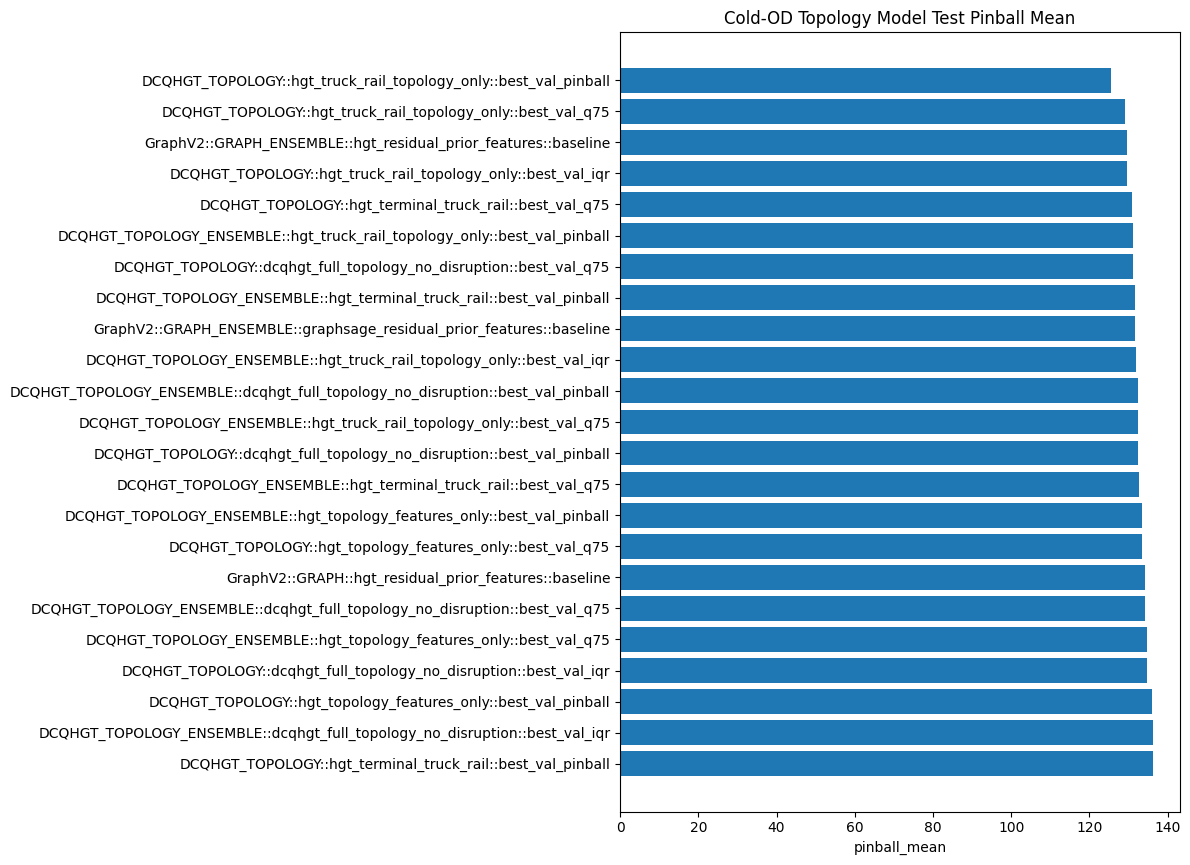

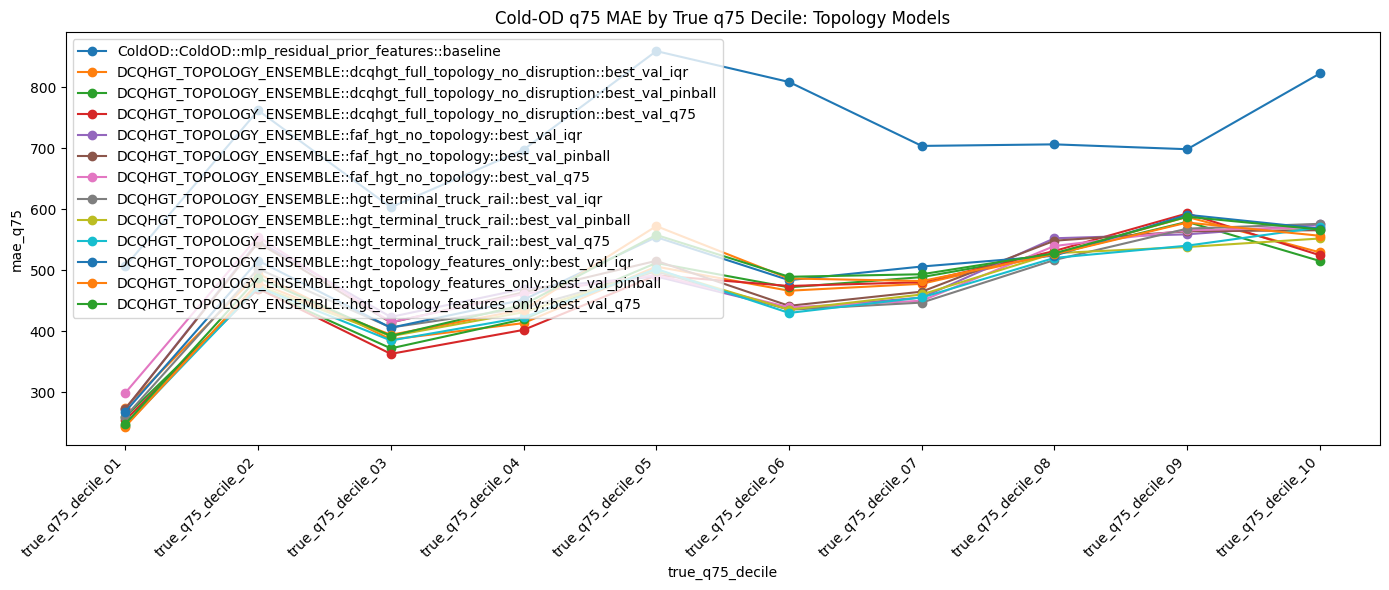

In [21]:

if cfg.make_plots and MATPLOTLIB_AVAILABLE:
    # Plot test leaderboard for topology and selected baselines.
    plot_leaderboard = leaderboard_test.head(25).copy()
    labels = plot_leaderboard["source"].astype(str) + "::" + plot_leaderboard["model"].astype(str) + "::" + plot_leaderboard["checkpoint"].astype(str)
    plt.figure(figsize=(12, max(6, len(plot_leaderboard) * 0.35)))
    plt.barh(labels[::-1], plot_leaderboard["pinball_mean"].to_numpy()[::-1])
    plt.xlabel("pinball_mean")
    plt.title("Cold-OD Topology Model Test Pinball Mean")
    plt.tight_layout()
    plt.savefig(paths.plots_dir / "dcqhgt_topology_leaderboard_pinball_mean.png", dpi=160)
    plt.show()

    # Plot q75 MAE by true q75 decile for a small selected set.
    if "true_q75_decile" in segment_tables:
        q75_seg = segment_tables["true_q75_decile"].copy()
        selected_models = [
            "dcqhgt_full_topology_no_disruption",
            "hgt_topology_features_only",
            "hgt_terminal_truck_rail",
            "faf_hgt_no_topology",
            "mlp_residual_prior_features",
        ]
        selected = q75_seg.loc[
            q75_seg["model"].isin(selected_models)
            & q75_seg["seed"].astype(str).isin(["ensemble", "baseline"])
        ].copy()
        if not selected.empty:
            plt.figure(figsize=(14, 6))
            for (source, model, checkpoint, seed), group in selected.groupby(["source", "model", "checkpoint", "seed"], dropna=False):
                group = group.sort_values("true_q75_decile")
                plt.plot(group["true_q75_decile"], group["mae_q75"], marker="o", label=f"{source}::{model}::{checkpoint}")
            plt.xticks(rotation=45, ha="right")
            plt.xlabel("true_q75_decile")
            plt.ylabel("mae_q75")
            plt.title("Cold-OD q75 MAE by True q75 Decile: Topology Models")
            plt.legend()
            plt.tight_layout()
            plt.savefig(paths.plots_dir / "dcqhgt_topology_q75_mae_by_true_q75_decile.png", dpi=160)
            plt.show()
else:
    print("Plotting skipped.")

## 22. Save artifacts

All prediction tables, metrics, segment summaries, paired diagnostics, model checkpoints, preprocessing metadata, and run configuration are saved here.

In [22]:

# Paths.
pred_by_seed_path = paths.output_dir / "predictions_dcqhgt_topology_v2_val_test_by_seed.parquet"
pred_ensemble_path = paths.output_dir / "predictions_dcqhgt_topology_v2_val_test_seed_ensemble.parquet"
combined_pred_path = paths.output_dir / "combined_predictions_dcqhgt_topology_v2_val_test.parquet"
metrics_by_seed_path = paths.output_dir / "metrics_dcqhgt_topology_v2_by_seed.csv"
metrics_ensemble_path = paths.output_dir / "metrics_dcqhgt_topology_v2_seed_ensemble.csv"
combined_metrics_path = paths.output_dir / "metrics_dcqhgt_topology_v2_combined.csv"
leaderboard_path = paths.output_dir / "leaderboard_test_dcqhgt_topology_v2.csv"
checkpoint_summary_path = paths.output_dir / "checkpoint_summary_dcqhgt_topology_v2.csv"
history_path = paths.output_dir / "training_history_dcqhgt_topology_v2.csv"
paired_summary_path = paths.output_dir / "paired_summary_dcqhgt_topology_v2_test_only.csv"
paired_rows_path = paths.output_dir / "paired_rows_dcqhgt_topology_v2_test_only.parquet"

# Save predictions and metrics.
safe_to_parquet(predictions_by_seed, pred_by_seed_path)
safe_to_parquet(predictions_seed_ensemble, pred_ensemble_path)
safe_to_parquet(combined_predictions, combined_pred_path)
metrics_by_seed.to_csv(metrics_by_seed_path, index=False)
metrics_seed_ensemble.to_csv(metrics_ensemble_path, index=False)
combined_metrics.to_csv(combined_metrics_path, index=False)
leaderboard_test.to_csv(leaderboard_path, index=False)
checkpoint_summary.to_csv(checkpoint_summary_path, index=False)
training_history.to_csv(history_path, index=False)
paired_summary.to_csv(paired_summary_path, index=False)
if not paired_rows.empty:
    safe_to_parquet(paired_rows, paired_rows_path)

# Save segment tables.
for segment_col, table in segment_tables.items():
    table.to_csv(paths.tables_dir / f"dcqhgt_topology_v2_test_only_segment_summary__{segment_col}.csv", index=False)

# Save checkpoints.
if cfg.save_models:
    for (variant_name, seed, checkpoint_name), state in all_checkpoint_states.items():
        model_path = paths.models_dir / f"{variant_name}__seed{seed}__{checkpoint_name}.pt"
        torch.save(
            {
                "state_dict": state["state_dict"],
                "variant": variant_name,
                "seed": seed,
                "checkpoint": checkpoint_name,
                "epoch": state["epoch"],
                "selection_value": state["selection_value"],
                "config": asdict(cfg),
            },
            model_path,
        )

# Save metadata.
write_json(
    {
        "manifest_feature_columns": manifest_feature_columns,
        "cold_prior_feature_columns": COLD_PRIOR_COLUMNS,
        "topology_feature_columns": topology_feature_columns,
        "base_edge_feature_columns": base_edge_feature_columns,
        "topology_edge_feature_columns": topology_edge_feature_columns,
        "label_columns": LABEL_COLUMNS,
    },
    paths.output_dir / "feature_columns_dcqhgt_topology_v2.json",
)

write_json(
    {
        "edge_preprocessor_base": edge_preprocessor_base.to_dict(),
        "edge_preprocessor_topology": edge_preprocessor_topology.to_dict(),
        "faf_node_mean": faf_node_mean.tolist(),
        "faf_node_std": faf_node_std.tolist(),
        "terminal_node_mean": terminal_node_mean.tolist(),
        "terminal_node_std": terminal_node_std.tolist(),
        "target_scale": target_scale,
        "year_to_idx": {str(k): int(v) for k, v in year_to_idx.items()},
    },
    paths.output_dir / "preprocessors_dcqhgt_topology_v2.json",
)

run_config = {
    "notebook": "DCQHGT_Topology_ColdOD_v2",
    "config": asdict(cfg),
    "paths": {key: str(value) for key, value in asdict(paths).items()},
    "dataset": {
        "n_rows": int(len(supervised_df)),
        "cold_split_counts": {key: int(value.sum()) for key, value in mask_dict.items()},
        "edge_feature_dim_base": int(edge_features_base_cpu.shape[1]),
        "edge_feature_dim_topology": int(edge_features_topology_cpu.shape[1]),
        "target_scale": float(target_scale),
        "n_faf_nodes": int(hetero_data["faf_zone"].x.shape[0]),
        "n_terminal_nodes": int(hetero_data["terminal"].x.shape[0]),
    },
    "package_versions": {
        "python": os.sys.version,
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "torch": torch.__version__,
        "cuda_available": torch.cuda.is_available(),
    },
}
write_json(run_config, paths.output_dir / "run_config_dcqhgt_topology_v2.json")

artifact_manifest = {
    "predictions_by_seed": str(pred_by_seed_path),
    "predictions_seed_ensemble": str(pred_ensemble_path),
    "combined_predictions": str(combined_pred_path),
    "leaderboard_test": str(leaderboard_path),
    "combined_metrics": str(combined_metrics_path),
    "checkpoint_summary": str(checkpoint_summary_path),
    "training_history": str(history_path),
    "paired_summary_test_only": str(paired_summary_path),
    "paired_rows_test_only": str(paired_rows_path) if not paired_rows.empty else None,
    "tables_dir": str(paths.tables_dir),
    "plots_dir": str(paths.plots_dir),
    "models_dir": str(paths.models_dir),
}
write_json(artifact_manifest, paths.output_dir / "analysis_artifact_manifest_dcqhgt_topology_v2.json")

print("Saved D-CQHGT topology artifacts to:", paths.output_dir)
print(json.dumps(artifact_manifest, indent=2))

Saved D-CQHGT topology artifacts to: E:\NetworkOptimization\pythonProject1\Data\10_experiments\dcqhgt_topology_cold_od_v2_notebook\east_plus_gulf
{
  "predictions_by_seed": "E:\\NetworkOptimization\\pythonProject1\\Data\\10_experiments\\dcqhgt_topology_cold_od_v2_notebook\\east_plus_gulf\\predictions_dcqhgt_topology_v2_val_test_by_seed.parquet",
  "predictions_seed_ensemble": "E:\\NetworkOptimization\\pythonProject1\\Data\\10_experiments\\dcqhgt_topology_cold_od_v2_notebook\\east_plus_gulf\\predictions_dcqhgt_topology_v2_val_test_seed_ensemble.parquet",
  "combined_predictions": "E:\\NetworkOptimization\\pythonProject1\\Data\\10_experiments\\dcqhgt_topology_cold_od_v2_notebook\\east_plus_gulf\\combined_predictions_dcqhgt_topology_v2_val_test.parquet",
  "leaderboard_test": "E:\\NetworkOptimization\\pythonProject1\\Data\\10_experiments\\dcqhgt_topology_cold_od_v2_notebook\\east_plus_gulf\\leaderboard_test_dcqhgt_topology_v2.csv",
  "combined_metrics": "E:\\NetworkOptimization\\pythonPro

## 23. Generate compact text report

This report avoids `DataFrame.to_markdown()` and therefore does not require the optional `tabulate` package.

In [23]:

report_lines = []
report_lines.append("# D-CQHGT Topology Cold-OD v2 Report")
report_lines.append("")
report_lines.append(f"Output directory: {paths.output_dir}")
report_lines.append(f"Enabled variants: {list(cfg.enabled_variant_names)}")
report_lines.append(f"Seeds: {list(cfg.seeds)}")
report_lines.append("")
report_lines.append("## Top test leaderboard rows")
report_lines.append(dataframe_to_text(
    leaderboard_test,
    ["rank", "source", "model", "checkpoint", "seed", "pinball_mean", "weighted_pinball_mean", "mae_q75", "iqr_mae", "stress_top10_mae_q75"],
    max_rows=30,
))
report_lines.append("")
report_lines.append("## Checkpoint summary")
report_lines.append(dataframe_to_text(
    checkpoint_summary,
    ["model", "seed", "checkpoint", "epoch", "selection_value", "checkpoint_val_pinball", "checkpoint_val_q75_mae", "checkpoint_val_iqr_mae"],
    max_rows=30,
))
report_lines.append("")
report_lines.append("## Paired comparison summary")
report_lines.append(dataframe_to_text(
    paired_summary.sort_values("mean_delta_pinball", ascending=False) if not paired_summary.empty else paired_summary,
    ["candidate_source", "candidate_model", "candidate_checkpoint", "candidate_seed", "n_rows", "mean_delta_pinball", "win_rate_pinball", "mean_delta_q75_abs_error", "win_rate_q75_abs_error"],
    max_rows=30,
))
report_lines.append("")
report_lines.append("## Interpretation guide")
report_lines.append("- If `dcqhgt_full_topology_no_disruption` beats FAF-zone HGT, topology/terminal information is adding value.")
report_lines.append("- If `hgt_topology_features_only` improves over FAF-zone HGT, explicit topology/path decoder features are useful.")
report_lines.append("- If `hgt_terminal_access_only` improves over FAF-zone HGT, terminal nodes and access edges are useful.")
report_lines.append("- If `hgt_truck_rail_topology_only` improves over FAF-zone HGT, truck/rail adjacency edges are useful.")
report_lines.append("- If the full topology model improves stress q75 and sparse q75, it supports the D-CQHGT topology contribution.")

report_path = paths.reports_dir / "dcqhgt_topology_cold_od_v2_report.md"
report_path.write_text("\n".join(report_lines), encoding="utf-8")
print("Wrote report:", report_path)
print("\n".join(report_lines[:20]))

Wrote report: E:\NetworkOptimization\pythonProject1\Data\10_experiments\dcqhgt_topology_cold_od_v2_notebook\east_plus_gulf\reports\dcqhgt_topology_cold_od_v2_report.md
# D-CQHGT Topology Cold-OD v2 Report

Output directory: E:\NetworkOptimization\pythonProject1\Data\10_experiments\dcqhgt_topology_cold_od_v2_notebook\east_plus_gulf
Enabled variants: ['faf_hgt_no_topology', 'hgt_topology_features_only', 'hgt_terminal_access_only', 'hgt_truck_rail_topology_only', 'hgt_terminal_truck_rail', 'dcqhgt_full_topology_no_disruption']
Seeds: [7, 42, 123, 2026, 535]

## Top test leaderboard rows
 rank                   source                              model       checkpoint     seed  pinball_mean  weighted_pinball_mean    mae_q75    iqr_mae  stress_top10_mae_q75
    1          DCQHGT_TOPOLOGY       hgt_truck_rail_topology_only best_val_pinball      123    125.420675             115.393245 468.984793 406.549749            505.614341
    2          DCQHGT_TOPOLOGY       hgt_truck_rail_topology_on